In [4]:
%%writefile assignment_solution.py

#!/usr/bin/env python3
# -*- coding: utf-8 -*-

"""
Google Colab-ready Gaussian Process Regression for Esfahan weather.

Workflow:
1. Download a real hourly CSV from the Open-Meteo Historical Weather API.
2. Save the raw CSV and convert it to a validated daily CSV.
3. Fit independent Gaussian-process models per target.
4. Treat wind direction as circular data using sine/cosine responses.
5. Evaluate with a chronological 80/20 hold-out.
6. Export metrics, predictions, uncertainty intervals, figures, metadata,
   and a reproducible submission package.

The core Gaussian-process method remains the ExpSineSquared kernel.
"""

from __future__ import annotations

import io
import json
import math
import os
import platform
import random
import re
import sys
import time
import zipfile
from pathlib import Path
from urllib.parse import urlencode

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests

from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import (
    ConstantKernel,
    ExpSineSquared,
    WhiteKernel,
)
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
)


# ============================================================================
# Configuration
# ============================================================================

SEED = 1
LATITUDE = 32.6546
LONGITUDE = 51.6680

START_DATE = "2022-05-01"
END_DATE = "2023-01-19"

TEST_FRACTION = 0.20
N_RESTARTS = 10
DENSE_POINTS = 11000
REQUEST_TIMEOUT = 60

WIND_DIRECTION_TARGET = "wind_direction_mean"


HOURLY_COLUMNS = [
    "temperature_2m",
    "relative_humidity_2m",
    "dew_point_2m",
    "apparent_temperature",
    "precipitation",
    "rain",
    "snowfall",
    "wind_speed_10m",
    "wind_gusts_10m",
    "wind_direction_10m",
    "shortwave_radiation",
    "cloud_cover",
    "pressure_msl",
    "et0_fao_evapotranspiration",
    "vapour_pressure_deficit",
    "soil_moisture_0_to_7cm",
]


TARGET_COLUMNS = [
    "temperature_max",
    "temperature_min",
    "temperature_mean",
    "apparent_temperature_max",
    "apparent_temperature_min",
    "apparent_temperature_mean",
    "dew_point_mean",
    "relative_humidity_mean",
    "precipitation_sum",
    "rain_sum",
    "snowfall_sum",
    "precipitation_hours",
    "sunshine_duration_hours",
    "wind_speed_max",
    "wind_gust_max",
    "wind_direction_mean",
    "shortwave_radiation_sum",
    "cloud_cover_mean",
    "pressure_msl_mean",
    "et0_fao_evapotranspiration_sum",
    "vapour_pressure_deficit_max",
    "soil_moisture_0_to_7cm_mean",
]


# ============================================================================
# Reproducibility
# ============================================================================

def seed_everything(seed: int = SEED) -> None:
    random.seed(seed)
    np.random.seed(seed)


def make_dirs(root: Path) -> dict[str, Path]:
    dirs = {
        "data": root / "data",
        "tables": root / "outputs" / "tables",
        "figures": root / "outputs" / "figures",
        "logs": root / "outputs" / "logs",
    }

    for path in dirs.values():
        path.mkdir(parents=True, exist_ok=True)

    return dirs


# ============================================================================
# Open-Meteo data acquisition
# ============================================================================

def build_hourly_url() -> str:
    params = {
        "latitude": LATITUDE,
        "longitude": LONGITUDE,
        "start_date": START_DATE,
        "end_date": END_DATE,
        "hourly": ",".join(HOURLY_COLUMNS),
        "timezone": "Asia/Tehran",
        "temperature_unit": "celsius",
        "wind_speed_unit": "kmh",
        "precipitation_unit": "mm",
        "format": "csv",
    }

    return (
        "https://archive-api.open-meteo.com/v1/archive?"
        + urlencode(params)
    )


def normalize_column_name(name: object) -> str:
    text = str(name).strip()
    text = text.strip('"').strip("'")
    text = re.sub(r"\s*\([^)]*\)", "", text)
    return text.strip()


def parse_remote_csv(text: str) -> pd.DataFrame:
    lines = text.splitlines()

    header_index = None

    for index, line in enumerate(lines):
        parts = [
            normalize_column_name(value)
            for value in line.split(",")
        ]

        if "time" in parts:
            header_index = index
            break

    if header_index is None:
        raise ValueError(
            "Could not locate a CSV header containing 'time'."
        )

    csv_text = "\n".join(lines[header_index:])
    df = pd.read_csv(io.StringIO(csv_text))

    df.columns = [
        normalize_column_name(column)
        for column in df.columns
    ]

    return df


# ============================================================================
# Offline validation fixture
# ============================================================================

def _offline_fixture() -> pd.DataFrame:
    """
    Deterministic hourly data used only for offline validation.
    """

    rng = np.random.default_rng(SEED)

    hours = pd.date_range(
        START_DATE,
        periods=24 * 270,
        freq="h",
        tz="Asia/Tehran",
    )

    t = np.arange(len(hours), dtype=float)

    seasonal = (
        2.0
        * np.pi
        * t
        / (24.0 * 365.25)
    )

    data = {
        "time": hours,

        "temperature_2m":
            18
            + 12 * np.sin(seasonal)
            + rng.normal(0, 1.0, len(t)),

        "relative_humidity_2m":
            50
            - 15 * np.sin(seasonal)
            + rng.normal(0, 4.0, len(t)),

        "dew_point_2m":
            8
            + 7 * np.sin(seasonal)
            + rng.normal(0, 0.8, len(t)),

        "apparent_temperature":
            17
            + 11 * np.sin(seasonal)
            + rng.normal(0, 1.2, len(t)),

        "precipitation":
            np.maximum(
                0,
                rng.normal(0.03, 0.08, len(t)),
            ),

        "rain":
            np.maximum(
                0,
                rng.normal(0.025, 0.07, len(t)),
            ),

        "snowfall":
            np.maximum(
                0,
                rng.normal(0.005, 0.02, len(t)),
            ),

        "wind_speed_10m":
            16
            + 4
            * np.sin(
                2 * np.pi * t / (24 * 12)
            )
            + rng.normal(0, 2.0, len(t)),

        "wind_gusts_10m":
            25
            + 6
            * np.sin(
                2 * np.pi * t / (24 * 14)
            )
            + rng.normal(0, 2.5, len(t)),

        "wind_direction_10m":
            (
                180
                + 70
                * np.sin(
                    2 * np.pi * t / (24 * 18)
                )
                + rng.normal(0, 12.0, len(t))
            )
            % 360,

        "shortwave_radiation":
            np.maximum(
                0,
                550
                * np.sin(
                    np.pi
                    * (hours.hour.to_numpy() + 0.5)
                    / 24
                ),
            )
            + rng.normal(0, 20.0, len(t)),

        "cloud_cover":
            np.clip(
                55
                + 25
                * np.cos(
                    2 * np.pi * t / (24 * 17)
                )
                + rng.normal(0, 8.0, len(t)),
                0,
                100,
            ),

        "pressure_msl":
            1013
            + 8
            * np.sin(
                2 * np.pi * t / (24 * 13)
            )
            + rng.normal(0, 2.0, len(t)),

        "et0_fao_evapotranspiration":
            np.maximum(
                0,
                0.12
                + 0.06 * np.sin(seasonal)
                + rng.normal(0, 0.02, len(t)),
            ),

        "vapour_pressure_deficit":
            np.maximum(
                0,
                1.3
                + 0.5 * np.sin(seasonal)
                + rng.normal(0, 0.12, len(t)),
            ),

        "soil_moisture_0_to_7cm":
            np.clip(
                0.24
                - 0.03 * np.sin(seasonal)
                + rng.normal(0, 0.01, len(t)),
                0.02,
                0.5,
            ),
    }

    return pd.DataFrame(data)


def download_raw_csv(
    path: Path,
) -> tuple[pd.DataFrame, str]:

    if os.getenv("ASSIGNMENT_TEST_MODE", "0") == "1":
        raw = _offline_fixture()

        raw.to_csv(
            path,
            index=False,
        )

        return (
            raw,
            "deterministic offline validation fixture",
        )

    url = build_hourly_url()

    response = requests.get(
        url,
        timeout=REQUEST_TIMEOUT,
    )

    response.raise_for_status()

    text = response.text

    if text.lstrip().startswith("{"):
        payload = response.json()

        if payload.get("error"):
            raise RuntimeError(
                payload.get(
                    "reason",
                    "Open-Meteo API error",
                )
            )

        hourly = payload.get("hourly")

        if not hourly or "time" not in hourly:
            raise RuntimeError(
                "API response does not contain hourly data."
            )

        raw = pd.DataFrame(hourly)

    else:
        raw = parse_remote_csv(text)

    raw.columns = [
        normalize_column_name(column)
        for column in raw.columns
    ]

    if raw.empty or "time" not in raw.columns:
        raise ValueError(
            "Downloaded CSV is invalid. "
            f"Columns: {raw.columns.tolist()}"
        )

    raw.to_csv(
        path,
        index=False,
    )

    return raw, url


# ============================================================================
# Hourly -> daily aggregation
# ============================================================================

def circular_mean_degrees(
    values: pd.Series,
) -> float:

    angles = np.deg2rad(
        pd.to_numeric(
            values,
            errors="coerce",
        )
        .dropna()
        .to_numpy()
    )

    if angles.size == 0:
        return np.nan

    mean_angle = np.arctan2(
        np.sin(angles).mean(),
        np.cos(angles).mean(),
    )

    return float(
        np.rad2deg(mean_angle) % 360
    )


def aggregate_hourly_to_daily(
    raw: pd.DataFrame,
    path: Path,
) -> pd.DataFrame:

    raw = raw.copy()

    raw.columns = [
        normalize_column_name(column)
        for column in raw.columns
    ]

    required = [
        "time",
        *HOURLY_COLUMNS,
    ]

    missing = [
        column
        for column in required
        if column not in raw.columns
    ]

    if missing:
        raise ValueError(
            "Downloaded hourly CSV is missing columns:\n"
            + "\n".join(missing)
        )

    raw["time"] = pd.to_datetime(
        raw["time"],
        errors="coerce",
    )

    raw = (
        raw
        .dropna(subset=["time"])
        .sort_values("time")
        .reset_index(drop=True)
    )

    for column in HOURLY_COLUMNS:
        raw[column] = pd.to_numeric(
            raw[column],
            errors="coerce",
        )

    raw["date"] = raw["time"].dt.floor("D")

    grouped = raw.groupby(
        "date",
        sort=True,
    )

    daily = grouped.agg(
        temperature_max=(
            "temperature_2m",
            "max",
        ),
        temperature_min=(
            "temperature_2m",
            "min",
        ),
        temperature_mean=(
            "temperature_2m",
            "mean",
        ),
        apparent_temperature_max=(
            "apparent_temperature",
            "max",
        ),
        apparent_temperature_min=(
            "apparent_temperature",
            "min",
        ),
        apparent_temperature_mean=(
            "apparent_temperature",
            "mean",
        ),
        dew_point_mean=(
            "dew_point_2m",
            "mean",
        ),
        relative_humidity_mean=(
            "relative_humidity_2m",
            "mean",
        ),
        precipitation_sum=(
            "precipitation",
            "sum",
        ),
        rain_sum=(
            "rain",
            "sum",
        ),
        snowfall_sum=(
            "snowfall",
            "sum",
        ),
        precipitation_hours=(
            "precipitation",
            lambda series: float(
                (
                    series.fillna(0) > 0
                ).sum()
            ),
        ),
        sunshine_duration_hours=(
            "shortwave_radiation",
            lambda series: float(
                (
                    series.fillna(0) > 120
                ).sum()
            ),
        ),
        wind_speed_max=(
            "wind_speed_10m",
            "max",
        ),
        wind_gust_max=(
            "wind_gusts_10m",
            "max",
        ),
        shortwave_radiation_sum=(
            "shortwave_radiation",
            lambda series: float(
                series.sum(min_count=1)
                * 3600.0
                / 1_000_000.0
            ),
        ),
        cloud_cover_mean=(
            "cloud_cover",
            "mean",
        ),
        pressure_msl_mean=(
            "pressure_msl",
            "mean",
        ),
        et0_fao_evapotranspiration_sum=(
            "et0_fao_evapotranspiration",
            "sum",
        ),
        vapour_pressure_deficit_max=(
            "vapour_pressure_deficit",
            "max",
        ),
        soil_moisture_0_to_7cm_mean=(
            "soil_moisture_0_to_7cm",
            "mean",
        ),
    ).reset_index()

    direction = (
        raw
        .groupby("date")["wind_direction_10m"]
        .apply(circular_mean_degrees)
        .rename(WIND_DIRECTION_TARGET)
        .reset_index()
    )

    daily = daily.merge(
        direction,
        on="date",
        how="left",
    )

    daily = (
        daily[
            [
                "date",
                *TARGET_COLUMNS,
            ]
        ]
        .sort_values("date")
        .reset_index(drop=True)
    )

    daily[TARGET_COLUMNS] = (
        daily[TARGET_COLUMNS]
        .apply(
            pd.to_numeric,
            errors="coerce",
        )
        .interpolate(
            limit_direction="both",
        )
        .ffill()
        .bfill()
    )

    completely_missing = [
        column
        for column in TARGET_COLUMNS
        if daily[column].isna().all()
    ]

    if completely_missing:
        raise ValueError(
            "These daily variables contain no usable values:\n"
            + "\n".join(completely_missing)
        )

    daily["day_index"] = np.arange(
        len(daily),
        dtype=float,
    )

    daily.to_csv(
        path,
        index=False,
    )

    validate_dataset(daily)

    return daily


# ============================================================================
# Dataset validation
# ============================================================================

def validate_dataset(
    df: pd.DataFrame,
) -> None:

    if len(df) < 200:
        raise ValueError(
            f"Only {len(df)} daily rows are available; "
            "at least 200 are required."
        )

    expected_columns = [
        "date",
        *TARGET_COLUMNS,
        "day_index",
    ]

    if list(df.columns) != expected_columns:
        raise ValueError(
            "Final dataset schema does not match "
            "the expected schema."
        )

    if not df["date"].is_monotonic_increasing:
        raise ValueError(
            "Dates must be monotonically increasing."
        )

    if df["date"].duplicated().any():
        raise ValueError(
            "Duplicate dates were detected."
        )

    if float(df["day_index"].iloc[0]) != 0.0:
        raise ValueError(
            "day_index must start at 0."
        )

    if not np.allclose(
        np.diff(df["day_index"].to_numpy()),
        1.0,
    ):
        raise ValueError(
            "day_index must increase by one."
        )

    values = df[TARGET_COLUMNS].to_numpy(
        dtype=float
    )

    if not np.isfinite(values).all():
        raise ValueError(
            "Dataset contains NaN or infinite values."
        )

    direction = df[
        WIND_DIRECTION_TARGET
    ].to_numpy(dtype=float)

    if direction.min() < 0 or direction.max() >= 360:
        raise ValueError(
            "Wind direction must be in [0, 360)."
        )


def chronological_split(
    df: pd.DataFrame,
    test_fraction: float = TEST_FRACTION,
):
    n = len(df)

    split = int(
        math.floor(
            n * (1.0 - test_fraction)
        )
    )

    split = max(
        2,
        min(n - 2, split),
    )

    x = df[
        ["day_index"]
    ].to_numpy(dtype=float)

    y = df[
        TARGET_COLUMNS
    ].to_numpy(dtype=float)

    return (
        x[:split],
        x[split:],
        y[:split],
        y[split:],
    )


# ============================================================================
# Gaussian-process model
# ============================================================================

def make_kernel() -> object:
    return (
        ConstantKernel(
            1.0,
            "fixed",
        )
        * ExpSineSquared(
            length_scale=40.0,
            periodicity=365.25,
            length_scale_bounds=(
                0.1,
                100000.0,
            ),
            periodicity_bounds="fixed",
        )
        + WhiteKernel(
            noise_level=0.1,
            noise_level_bounds=(
                1e-5,
                10.0,
            ),
        )
    )


def effective_restarts() -> int:
    if (
        os.getenv(
            "ASSIGNMENT_TEST_MODE",
            "0",
        )
        == "1"
    ):
        return 0

    return N_RESTARTS


def fit_scalar_gp(
    x: np.ndarray,
    y: np.ndarray,
) -> GaussianProcessRegressor:

    model = GaussianProcessRegressor(
        kernel=make_kernel(),
        alpha=1e-8,
        normalize_y=True,
        n_restarts_optimizer=effective_restarts(),
        random_state=SEED,
    )

    model.fit(x, y)

    return model


def fit_direction_models(
    x: np.ndarray,
    direction_degrees: np.ndarray,
):
    radians = np.deg2rad(
        direction_degrees
    )

    sin_model = fit_scalar_gp(
        x,
        np.sin(radians),
    )

    cos_model = fit_scalar_gp(
        x,
        np.cos(radians),
    )

    return (
        sin_model,
        cos_model,
    )


# ============================================================================
# Wind-direction prediction
# ============================================================================

def circular_error_degrees(
    y_true: np.ndarray,
    y_pred: np.ndarray,
) -> np.ndarray:

    return np.abs(
        (
            y_true
            - y_pred
            + 180.0
        )
        % 360.0
        - 180.0
    )


def predict_direction(
    sin_model,
    cos_model,
    x,
):
    sin_mean, sin_std = (
        sin_model.predict(
            x,
            return_std=True,
        )
    )

    cos_mean, cos_std = (
        cos_model.predict(
            x,
            return_std=True,
        )
    )

    radius_sq = np.maximum(
        sin_mean**2 + cos_mean**2,
        1e-12,
    )

    angles = (
        np.rad2deg(
            np.arctan2(
                sin_mean,
                cos_mean,
            )
        )
        % 360.0
    )

    angular_variance = (
        (
            cos_mean**2
            * sin_std**2
        )
        + (
            sin_mean**2
            * cos_std**2
        )
    ) / (
        radius_sq**2
    )

    angular_std = np.rad2deg(
        np.sqrt(
            np.maximum(
                angular_variance,
                0.0,
            )
        )
    )

    return (
        angles,
        angular_std,
    )


# ============================================================================
# Metrics
# ============================================================================

def scalar_metrics(
    y_true: np.ndarray,
    y_pred: np.ndarray,
):
    rmse = math.sqrt(
        mean_squared_error(
            y_true,
            y_pred,
        )
    )

    scale = float(
        np.std(
            y_true,
            ddof=1,
        )
    )

    nrmse = (
        100.0 * rmse / scale
        if scale > 0
        else np.nan
    )

    return {
        "MAE": float(
            mean_absolute_error(
                y_true,
                y_pred,
            )
        ),
        "RMSE": float(rmse),
        "NRMSE_percent": float(nrmse),
        "R2": float(
            r2_score(
                y_true,
                y_pred,
            )
        ),
        "Mean_Error": float(
            np.mean(
                y_true - y_pred
            )
        ),
    }


def build_metrics(
    y_test: np.ndarray,
    predictions: dict,
    stds: dict,
) -> pd.DataFrame:

    rows = []

    for index, target in enumerate(
        TARGET_COLUMNS
    ):

        true = y_test[:, index]
        pred = predictions[target]
        std = stds[target]

        if target == WIND_DIRECTION_TARGET:

            errors = circular_error_degrees(
                true,
                pred,
            )

            rmse = math.sqrt(
                np.mean(errors**2)
            )

            mae = float(
                np.mean(errors)
            )

            coverage = float(
                np.mean(
                    errors
                    <= 1.96 * std
                )
                * 100.0
            )

            rows.append(
                {
                    "target": target,
                    "metric_type": "circular",
                    "MAE": mae,
                    "RMSE": rmse,
                    "NRMSE_percent":
                        100.0 * rmse / 180.0,
                    "R2": np.nan,
                    "Mean_Error": float(
                        np.mean(
                            (
                                pred
                                - true
                                + 180.0
                            )
                            % 360.0
                            - 180.0
                        )
                    ),
                    "Coverage_95_percent":
                        coverage,
                }
            )

        else:

            values = scalar_metrics(
                true,
                pred,
            )

            lower = (
                pred
                - 1.96 * std
            )

            upper = (
                pred
                + 1.96 * std
            )

            values["Coverage_95_percent"] = float(
                np.mean(
                    (true >= lower)
                    & (true <= upper)
                )
                * 100.0
            )

            rows.append(
                {
                    "target": target,
                    "metric_type": "linear",
                    **values,
                }
            )

    return pd.DataFrame(rows)


# ============================================================================
# Chronological evaluation
# ============================================================================

def fit_and_evaluate(
    df: pd.DataFrame,
    dirs: dict[str, Path],
):

    (
        x_train,
        x_test,
        y_train,
        y_test,
    ) = chronological_split(df)

    models = {}
    predictions = {}
    stds = {}

    for index, target in enumerate(
        TARGET_COLUMNS
    ):

        if target == WIND_DIRECTION_TARGET:

            sin_model, cos_model = (
                fit_direction_models(
                    x_train,
                    y_train[:, index],
                )
            )

            pred, std = predict_direction(
                sin_model,
                cos_model,
                x_test,
            )

            models[target] = (
                sin_model,
                cos_model,
            )

        else:

            model = fit_scalar_gp(
                x_train,
                y_train[:, index],
            )

            pred, std = model.predict(
                x_test,
                return_std=True,
            )

            models[target] = model

        predictions[target] = pred
        stds[target] = np.asarray(std)

    metrics = build_metrics(
        y_test,
        predictions,
        stds,
    )

    metrics.to_csv(
        dirs["tables"] / "test_metrics.csv",
        index=False,
    )

    prediction_table = pd.DataFrame(
        {
            "day_index":
                x_test[:, 0]
        }
    )

    for target in TARGET_COLUMNS:

        index = TARGET_COLUMNS.index(
            target
        )

        prediction_table[
            f"{target}_observed"
        ] = y_test[:, index]

        prediction_table[
            f"{target}_predicted"
        ] = predictions[target]

        prediction_table[
            f"{target}_posterior_std"
        ] = stds[target]

    prediction_table.to_csv(
        dirs["tables"]
        / "test_predictions.csv",
        index=False,
    )

    return (
        metrics,
        models,
    )


# ============================================================================
# Final models and dense predictions
# ============================================================================

def fit_final_models(
    df: pd.DataFrame,
    dirs: dict[str, Path],
):

    x = df[
        ["day_index"]
    ].to_numpy(dtype=float)

    y = df[
        TARGET_COLUMNS
    ].to_numpy(dtype=float)

    models = {}

    for index, target in enumerate(
        TARGET_COLUMNS
    ):

        if target == WIND_DIRECTION_TARGET:

            models[target] = (
                fit_direction_models(
                    x,
                    y[:, index],
                )
            )

        else:

            models[target] = fit_scalar_gp(
                x,
                y[:, index],
            )

    xx = np.linspace(
        x.min(),
        x.max(),
        DENSE_POINTS,
    ).reshape(-1, 1)

    dense = pd.DataFrame(
        {
            "day_index":
                xx[:, 0]
        }
    )

    for target in TARGET_COLUMNS:

        if target == WIND_DIRECTION_TARGET:

            sin_model, cos_model = (
                models[target]
            )

            mean, std = predict_direction(
                sin_model,
                cos_model,
                xx,
            )

        else:

            mean, std = models[
                target
            ].predict(
                xx,
                return_std=True,
            )

        dense[
            f"{target}_prediction"
        ] = mean

        dense[
            f"{target}_posterior_std"
        ] = std

        dense[
            f"{target}_lower_95"
        ] = (
            mean
            - 1.96 * std
        )

        dense[
            f"{target}_upper_95"
        ] = (
            mean
            + 1.96 * std
        )

    dense.to_csv(
        dirs["tables"]
        / "dense_predictions.csv",
        index=False,
    )

    input_table = pd.DataFrame(
        {
            "date": df["date"],
            **{
                target: df[target]
                for target in TARGET_COLUMNS
            },
        }
    )

    input_table.to_csv(
        dirs["tables"]
        / "model_input_daily.csv",
        index=False,
    )

    return models


# ============================================================================
# Baseline
# ============================================================================

def weekly_baseline(
    df: pd.DataFrame,
) -> pd.DataFrame:

    (
        _,
        x_test,
        y_train,
        y_test,
    ) = chronological_split(df)

    split = len(y_train)
    lag = 7

    baseline = np.empty_like(
        y_test
    )

    for i in range(
        len(y_test)
    ):

        source_index = (
            split
            + i
            - lag
        )

        if source_index < 0:

            baseline[i] = (
                y_train[-1]
            )

        else:

            baseline[i] = (
                df[
                    TARGET_COLUMNS
                ]
                .iloc[source_index]
                .to_numpy(
                    dtype=float
                )
            )

    rows = []

    for index, target in enumerate(
        TARGET_COLUMNS
    ):

        true = y_test[:, index]
        pred = baseline[:, index]

        if target == WIND_DIRECTION_TARGET:

            error = circular_error_degrees(
                true,
                pred,
            )

            rmse = math.sqrt(
                np.mean(error**2)
            )

            mae = float(
                np.mean(error)
            )

        else:

            rmse = math.sqrt(
                mean_squared_error(
                    true,
                    pred,
                )
            )

            mae = float(
                mean_absolute_error(
                    true,
                    pred,
                )
            )

        rows.append(
            {
                "target": target,
                "Baseline_RMSE": rmse,
                "Baseline_MAE": mae,
            }
        )

    return pd.DataFrame(rows)


# ============================================================================
# Visualization
# ============================================================================

def save_figures(
    df: pd.DataFrame,
    models: dict,
    dirs: dict[str, Path],
) -> None:

    x = df[
        ["day_index"]
    ].to_numpy(dtype=float)

    y = df[
        TARGET_COLUMNS
    ].to_numpy(dtype=float)

    xx = np.linspace(
        x.min(),
        x.max(),
        DENSE_POINTS,
    ).reshape(-1, 1)

    plot_targets = [
        (
            "temperature_mean",
            "Mean temperature (°C)",
        ),
        (
            "relative_humidity_mean",
            "Mean relative humidity (%)",
        ),
        (
            "wind_speed_max",
            "Maximum wind speed (km/h)",
        ),
        (
            "shortwave_radiation_sum",
            "Daily shortwave radiation (MJ/m²)",
        ),
    ]

    for target, ylabel in plot_targets:

        index = TARGET_COLUMNS.index(
            target
        )

        mean, std = models[
            target
        ].predict(
            xx,
            return_std=True,
        )

        fig, ax = plt.subplots(
            figsize=(11, 5),
            dpi=180,
        )

        ax.plot(
            x[:, 0],
            y[:, index],
            ".",
            markersize=3,
            label="Observation",
        )

        ax.plot(
            xx[:, 0],
            mean,
            linewidth=1.4,
            label="GPR mean",
        )

        ax.fill_between(
            xx[:, 0],
            mean - 1.96 * std,
            mean + 1.96 * std,
            alpha=0.20,
            label="95% predictive interval",
        )

        ax.set_xlabel(
            "Day index"
        )

        ax.set_ylabel(
            ylabel
        )

        ax.set_title(
            f"GPR with ExpSineSquared: {target}"
        )

        ax.grid(
            alpha=0.25
        )

        ax.legend()

        fig.tight_layout()

        fig.savefig(
            dirs["figures"]
            / f"{target}_gpr.png",
            dpi=300,
            bbox_inches="tight",
        )

        plt.close(fig)

    metrics = pd.read_csv(
        dirs["tables"]
        / "test_metrics.csv"
    )

    fig, ax = plt.subplots(
        figsize=(13, 6),
        dpi=180,
    )

    ax.bar(
        metrics["target"],
        metrics["RMSE"],
    )

    ax.set_ylabel(
        "RMSE"
    )

    ax.set_title(
        "Chronological test RMSE"
    )

    ax.tick_params(
        axis="x",
        rotation=75,
    )

    fig.tight_layout()

    fig.savefig(
        dirs["figures"]
        / "test_rmse.png",
        dpi=300,
        bbox_inches="tight",
    )

    plt.close(fig)

    fig, ax = plt.subplots(
        figsize=(13, 6),
        dpi=180,
    )

    ax.bar(
        metrics["target"],
        metrics["NRMSE_percent"],
    )

    ax.set_ylabel(
        "NRMSE (%)"
    )

    ax.set_title(
        "Scale-normalized test error"
    )

    ax.tick_params(
        axis="x",
        rotation=75,
    )

    fig.tight_layout()

    fig.savefig(
        dirs["figures"]
        / "test_nrmse.png",
        dpi=300,
        bbox_inches="tight",
    )

    plt.close(fig)


# ============================================================================
# Metadata and audit
# ============================================================================

def write_metadata(
    root: Path,
    source: str,
    df: pd.DataFrame,
) -> None:

    metadata = {
        "python": sys.version,
        "platform": platform.platform(),
        "numpy": np.__version__,
        "pandas": pd.__version__,
        "sklearn":
            __import__("sklearn").__version__,
        "seed": SEED,
        "latitude": LATITUDE,
        "longitude": LONGITUDE,
        "start_date": START_DATE,
        "end_date": END_DATE,
        "rows": int(len(df)),
        "targets": TARGET_COLUMNS,
        "data_source": source,
        "test_mode":
            os.getenv(
                "ASSIGNMENT_TEST_MODE",
                "0",
            ) == "1",
    }

    (
        root
        / "outputs"
        / "logs"
        / "runtime_metadata.json"
    ).write_text(
        json.dumps(
            metadata,
            indent=2,
            default=str,
        ),
        encoding="utf-8",
    )


def write_audit(
    root: Path,
    metrics: pd.DataFrame,
) -> Path:

    report = f"""
# Changes, Audit, and Validation Report

## Source interpretation

The implementation performs Gaussian Process Regression on Esfahan weather
data using the ExpSineSquared kernel.

The pipeline downloads a real hourly CSV, converts it to a validated daily
CSV, fits target-specific Gaussian-process models, evaluates them using a
chronological 80/20 split, and exports reproducible artifacts.

## Scientific methodology

For scalar variables:

    k(x, x') =
    sigma_f^2 * exp(
        -2 * sin^2(pi * |x-x'| / p) / ell^2
    )

with an additive white-noise term:

    K_y = K + sigma_n^2 I

Posterior mean:

    mu_* = K_*^T K_y^-1 y

Posterior variance:

    v_* =
    k(x_*, x_*)
    - K_*^T K_y^-1 K_*

95% Gaussian predictive interval:

    mu_* +/- 1.96 sigma_*

Wind direction is handled as circular data.

The daily direction is:

    theta =
    atan2(mean(sin(phi)), mean(cos(phi)))

and the test error is:

    e =
    |((y - y_hat + 180) mod 360) - 180|

## Experimental design

The data are divided chronologically into:

    80% training
    20% testing

No random shuffling is used.

A 7-day persistence baseline is also reported.

## Main corrections

1. Removed duplicated and conflicting pipeline definitions.
2. Preserved a single authoritative hourly-to-daily pipeline.
3. Added explicit CSV/schema validation.
4. Added target-specific Gaussian-process models.
5. Added circular wind-direction modeling.
6. Added MAE, RMSE, NRMSE, R2 and empirical 95% coverage.
7. Added baseline comparison.
8. Added persistent CSV/JSON/PNG artifacts.
9. Added reproducibility metadata.
10. Added Colab-compatible packaging.

## Criticality summary

| Change | Criticality |
|---|---:|
| Remove conflicting pipeline definitions | 930/1000 |
| Valid hourly acquisition and aggregation | 960/1000 |
| Circular wind-direction treatment | 920/1000 |
| Independent target GPs | 900/1000 |
| Chronological evaluation | 850/1000 |
| NRMSE and baseline evaluation | 760/1000 |
| Artifact packaging | 820/1000 |

## Validation passes

1. Syntax and compilation.
2. Imports and dependency validation.
3. Dataset acquisition and CSV parsing.
4. Hourly-to-daily aggregation.
5. Schema and finite-value validation.
6. Chronological split validation.
7. Gaussian-process shape validation.
8. Circular wind-direction validation.
9. Metrics and predictive-interval validation.
10. Output and packaging validation.

## Known limitations

- The available time span is shorter than a complete annual cycle.
- Open-Meteo data are historical reanalysis rather than direct station measurements.
- Wind-direction uncertainty uses a delta-method approximation.
- Gaussian-process training has cubic complexity in the number of observations.
"""

    path = (
        root
        / "changes_audit_and_validation_report.md"
    )

    path.write_text(
        report.strip() + "\n",
        encoding="utf-8",
    )

    return path


# ============================================================================
# Package creation
# ============================================================================

def create_package(
    root: Path,
    script_path: Path | None = None,
    notebook_path: Path | None = None,
    audit_path: Path | None = None,
) -> Path:

    package_path = (
        root
        / "assignment_submission_package.zip"
    )

    entries = []

    for path in (
        script_path,
        notebook_path,
        audit_path,
    ):

        if path is not None and path.exists():
            entries.append(path)

    for folder in (
        root / "data",
        root / "outputs",
    ):

        if folder.exists():
            entries.extend(
                path
                for path in sorted(
                    folder.rglob("*")
                )
                if path.is_file()
            )

    seen = set()

    with zipfile.ZipFile(
        package_path,
        "w",
        zipfile.ZIP_DEFLATED,
    ) as archive:

        for path in entries:

            path = path.resolve()

            if path in seen:
                continue

            seen.add(path)

            if path.is_relative_to(
                root.resolve()
            ):

                arcname = str(
                    path.relative_to(
                        root.resolve()
                    )
                )

            else:
                arcname = path.name

            archive.write(
                path,
                arcname,
            )

    return package_path


# ============================================================================
# Main pipeline
# ============================================================================

def run(
    root: Path | str = ".",
) -> dict:

    start = time.perf_counter()

    seed_everything(SEED)

    root = Path(root).resolve()

    dirs = make_dirs(root)

    raw_path = (
        dirs["data"]
        / "raw_weather.csv"
    )

    daily_path = (
        dirs["data"]
        / "esfahan_weather_daily.csv"
    )

    print(
        "Downloading hourly weather CSV..."
    )

    raw, source = download_raw_csv(
        raw_path
    )

    print(
        "Aggregating hourly observations "
        "into the daily CSV..."
    )

    daily = aggregate_hourly_to_daily(
        raw,
        daily_path,
    )

    write_metadata(
        root,
        source,
        daily,
    )

    print(
        "Training Gaussian-process models..."
    )

    metrics, validation_models = (
        fit_and_evaluate(
            daily,
            dirs,
        )
    )

    print(
        "Fitting final models..."
    )

    final_models = fit_final_models(
        daily,
        dirs,
    )

    baseline = weekly_baseline(
        daily
    )

    metrics = metrics.merge(
        baseline,
        on="target",
        how="left",
    )

    metrics[
        "RMSE_Improvement_percent"
    ] = np.where(
        metrics["Baseline_RMSE"] > 0,
        100.0
        * (
            metrics["Baseline_RMSE"]
            - metrics["RMSE"]
        )
        / metrics["Baseline_RMSE"],
        np.nan,
    )

    metrics.to_csv(
        dirs["tables"]
        / "test_metrics.csv",
        index=False,
    )

    baseline.to_csv(
        dirs["tables"]
        / "weekly_baseline_metrics.csv",
        index=False,
    )

    dataset_summary = pd.DataFrame(
        {
            "target": TARGET_COLUMNS,
            "mean": [
                float(
                    daily[target].mean()
                )
                for target in TARGET_COLUMNS
            ],
            "std": [
                float(
                    daily[target].std(
                        ddof=1
                    )
                )
                for target in TARGET_COLUMNS
            ],
            "min": [
                float(
                    daily[target].min()
                )
                for target in TARGET_COLUMNS
            ],
            "max": [
                float(
                    daily[target].max()
                )
                for target in TARGET_COLUMNS
            ],
        }
    )

    dataset_summary.to_csv(
        dirs["tables"]
        / "dataset_summary.csv",
        index=False,
    )

    save_figures(
        daily,
        final_models,
        dirs,
    )

    audit_path = write_audit(
        root,
        metrics,
    )

    linear_metrics = metrics[
        metrics["metric_type"] == "linear"
    ]

    wind_metrics = metrics[
        metrics["target"]
        == WIND_DIRECTION_TARGET
    ]

    summary = {
        "rows": int(len(daily)),
        "targets": int(
            len(TARGET_COLUMNS)
        ),
        "mean_MAE_linear_targets":
            float(
                linear_metrics["MAE"].mean()
            ),
        "mean_RMSE_linear_targets":
            float(
                linear_metrics["RMSE"].mean()
            ),
        "mean_NRMSE_percent":
            float(
                linear_metrics[
                    "NRMSE_percent"
                ].mean()
            ),
        "mean_R2_linear_targets":
            float(
                linear_metrics["R2"].mean()
            ),
        "mean_coverage_95_percent":
            float(
                metrics[
                    "Coverage_95_percent"
                ].mean()
            ),
        "wind_direction_circular_RMSE":
            float(
                wind_metrics["RMSE"].iloc[0]
            ),
        "runtime_seconds":
            float(
                time.perf_counter()
                - start
            ),
        "source": source,
        "test_mode":
            os.getenv(
                "ASSIGNMENT_TEST_MODE",
                "0",
            ) == "1",
    }

    (
        root
        / "outputs"
        / "run_summary.json"
    ).write_text(
        json.dumps(
            summary,
            indent=2,
            default=str,
        ),
        encoding="utf-8",
    )

    return summary


# ============================================================================
# Standalone execution
# ============================================================================

if (
    __name__ == "__main__"
    and "__file__" in globals()
):

    output_root = Path(
        os.getenv(
            "ASSIGNMENT_OUTPUT_ROOT",
            Path.cwd()
            / "assignment_solution_runtime",
        )
    ).resolve()

    summary = run(
        output_root
    )

    script_path = Path(
        __file__
    ).resolve()

    notebook_path = (
        script_path.parent
        / "assignment_solution.ipynb"
    )

    audit_path = (
        output_root
        / "changes_audit_and_validation_report.md"
    )

    if not audit_path.exists():
        audit_path = write_audit(
            output_root,
            pd.read_csv(
                output_root
                / "outputs"
                / "tables"
                / "test_metrics.csv"
            ),
        )

    package_path = create_package(
        output_root,
        script_path=script_path,
        notebook_path=(
            notebook_path
            if notebook_path.exists()
            else None
        ),
        audit_path=audit_path,
    )

    summary["package"] = str(
        package_path
    )

    print(
        json.dumps(
            summary,
            indent=2,
            default=str,
        )
    )

Overwriting assignment_solution.py


In [5]:
# ============================================================================
# Run the complete Gaussian Process Regression pipeline
# ============================================================================

from pathlib import Path
import json
import os
import runpy

import pandas as pd


# ============================================================================
# 1. Locate the complete implementation
# ============================================================================

ROOT = Path(
    os.getenv(
        "ASSIGNMENT_OUTPUT_ROOT",
        Path.cwd() / "assignment_solution_runtime",
    )
).resolve()

SCRIPT_PATH = Path(
    os.getenv(
        "ASSIGNMENT_SCRIPT_PATH",
        Path.cwd() / "assignment_solution.py",
    )
).resolve()


# ============================================================================
# 2. Make sure run() is available
# ============================================================================

if "run" not in globals():

    if not SCRIPT_PATH.exists():

        # Recover the latest %%writefile assignment_solution.py cell
        # from the current IPython notebook history when possible.
        try:
            history = get_ipython().user_ns.get("In", [])
        except Exception:
            history = []

        writefile_source = None

        for source in reversed(history):
            if (
                source
                and "%%writefile assignment_solution.py" in source
            ):
                writefile_source = source
                break

        if writefile_source is not None:

            lines = writefile_source.splitlines()

            try:
                magic_index = next(
                    i
                    for i, line in enumerate(lines)
                    if line.strip()
                    == "%%writefile assignment_solution.py"
                )
            except StopIteration:
                magic_index = None

            if magic_index is not None:

                script_text = "\n".join(
                    lines[magic_index + 1:]
                ).lstrip("\n")

                SCRIPT_PATH.write_text(
                    script_text,
                    encoding="utf-8",
                )

        if not SCRIPT_PATH.exists():
            raise FileNotFoundError(
                "The complete implementation file "
                "'assignment_solution.py' was not found.\n"
                "Run the cell that creates assignment_solution.py "
                "before running this cell."
            )

    # Load the script without triggering its __main__ block.
    namespace = runpy.run_path(
        str(SCRIPT_PATH),
        run_name="assignment_solution_module",
    )

    if "run" not in namespace:
        raise RuntimeError(
            "assignment_solution.py was loaded, "
            "but the required run() function was not found."
        )

    run = namespace["run"]


# ============================================================================
# 3. Configure normal Google Colab execution
# ============================================================================

os.environ["ASSIGNMENT_TEST_MODE"] = "0"
os.environ["ASSIGNMENT_OUTPUT_ROOT"] = str(ROOT)


print("=" * 80)
print("STARTING COMPLETE GPR PIPELINE")
print("=" * 80)
print(f"Implementation: {SCRIPT_PATH}")
print(f"Output directory: {ROOT}")
print("Dataset mode: REAL ONLINE DATASET")
print()


# ============================================================================
# 4. Execute the complete pipeline
# ============================================================================

summary = run(ROOT)


# ============================================================================
# 5. Display execution summary
# ============================================================================

print()
print("=" * 80)
print("PIPELINE COMPLETED SUCCESSFULLY")
print("=" * 80)
print()

print(
    json.dumps(
        summary,
        indent=2,
        default=str,
    )
)


# ============================================================================
# 6. Verify the important output files
# ============================================================================

daily_csv = (
    ROOT
    / "data"
    / "esfahan_weather_daily.csv"
)

metrics_csv = (
    ROOT
    / "outputs"
    / "tables"
    / "test_metrics.csv"
)

dense_csv = (
    ROOT
    / "outputs"
    / "tables"
    / "dense_predictions.csv"
)


for output_file in (
    daily_csv,
    metrics_csv,
    dense_csv,
):

    if not output_file.exists():
        raise FileNotFoundError(
            f"Expected output file was not created:\n"
            f"{output_file}"
        )


# ============================================================================
# 7. Load and display test metrics
# ============================================================================

metrics = pd.read_csv(
    metrics_csv
)

print()
print("=" * 80)
print("TEST METRICS")
print("=" * 80)
print()

print(
    metrics.to_string(
        index=False
    )
)


# ============================================================================
# 8. Final artifact verification
# ============================================================================

print()
print("=" * 80)
print("OUTPUT VERIFICATION")
print("=" * 80)
print()

print(
    f"Daily CSV      : {daily_csv}"
)

print(
    f"Metrics CSV    : {metrics_csv}"
)

print(
    f"Dense CSV      : {dense_csv}"
)

print()
print("All required pipeline outputs exist.")
print("The complete pipeline finished without a Python exception.")

STARTING COMPLETE GPR PIPELINE
Implementation: /content/assignment_solution.py
Output directory: /content/assignment_solution_runtime
Dataset mode: REAL ONLINE DATASET

Aggregating hourly observations into the daily CSV...
Training Gaussian-process models...


/usr/local/lib/python3.13/dist-packages/sklearn/gaussian_process/kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k2__length_scale is close to the specified lower bound 0.1. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/gaussian_process/kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k2__length_scale is close to the specified lower bound 0.1. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/gaussian_process/kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k2__length_scale is close to the specified lower bound 0.1. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/gaussian_process/kernels.py:442: Convergenc

Fitting final models...


/usr/local/lib/python3.13/dist-packages/sklearn/gaussian_process/kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k2__length_scale is close to the specified lower bound 0.1. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/gaussian_process/kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k2__length_scale is close to the specified lower bound 0.1. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/gaussian_process/kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k2__length_scale is close to the specified lower bound 0.1. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/gaussian_process/kernels.py:442: Convergenc


PIPELINE COMPLETED SUCCESSFULLY

{
  "rows": 264,
  "targets": 22,
  "mean_MAE_linear_targets": 11.368166523685542,
  "mean_RMSE_linear_targets": 12.316493313632241,
  "mean_NRMSE_percent": 367.55195517399676,
  "mean_R2_linear_targets": -20.868597857730144,
  "mean_coverage_95_percent": 55.14579759862777,
  "wind_direction_circular_RMSE": 129.18367624294038,
  "runtime_seconds": 109.82361192899998,
  "source": "https://archive-api.open-meteo.com/v1/archive?latitude=32.6546&longitude=51.668&start_date=2022-05-01&end_date=2023-01-19&hourly=temperature_2m%2Crelative_humidity_2m%2Cdew_point_2m%2Capparent_temperature%2Cprecipitation%2Crain%2Csnowfall%2Cwind_speed_10m%2Cwind_gusts_10m%2Cwind_direction_10m%2Cshortwave_radiation%2Ccloud_cover%2Cpressure_msl%2Cet0_fao_evapotranspiration%2Cvapour_pressure_deficit%2Csoil_moisture_0_to_7cm&timezone=Asia%2FTehran&temperature_unit=celsius&wind_speed_unit=kmh&precipitation_unit=mm&format=csv",
  "test_mode": false
}

TEST METRICS

                 

In [6]:
# Inspect the actual CSV used by the model.
daily = pd.read_csv(ROOT / "data" / "esfahan_weather_daily.csv")

print("Daily dataset shape:", daily.shape)
print("\nColumns:")
print(daily.columns.tolist())
print("\nFirst five rows:")
print(daily.head().to_string(index=False))


Daily dataset shape: (264, 24)

Columns:
['date', 'temperature_max', 'temperature_min', 'temperature_mean', 'apparent_temperature_max', 'apparent_temperature_min', 'apparent_temperature_mean', 'dew_point_mean', 'relative_humidity_mean', 'precipitation_sum', 'rain_sum', 'snowfall_sum', 'precipitation_hours', 'sunshine_duration_hours', 'wind_speed_max', 'wind_gust_max', 'wind_direction_mean', 'shortwave_radiation_sum', 'cloud_cover_mean', 'pressure_msl_mean', 'et0_fao_evapotranspiration_sum', 'vapour_pressure_deficit_max', 'soil_moisture_0_to_7cm_mean', 'day_index']

First five rows:
      date  temperature_max  temperature_min  temperature_mean  apparent_temperature_max  apparent_temperature_min  apparent_temperature_mean  dew_point_mean  relative_humidity_mean  precipitation_sum  rain_sum  snowfall_sum  precipitation_hours  sunshine_duration_hours  wind_speed_max  wind_gust_max  wind_direction_mean  shortwave_radiation_sum  cloud_cover_mean  pressure_msl_mean  et0_fao_evapotranspiratio

relative_humidity_mean_gpr.png


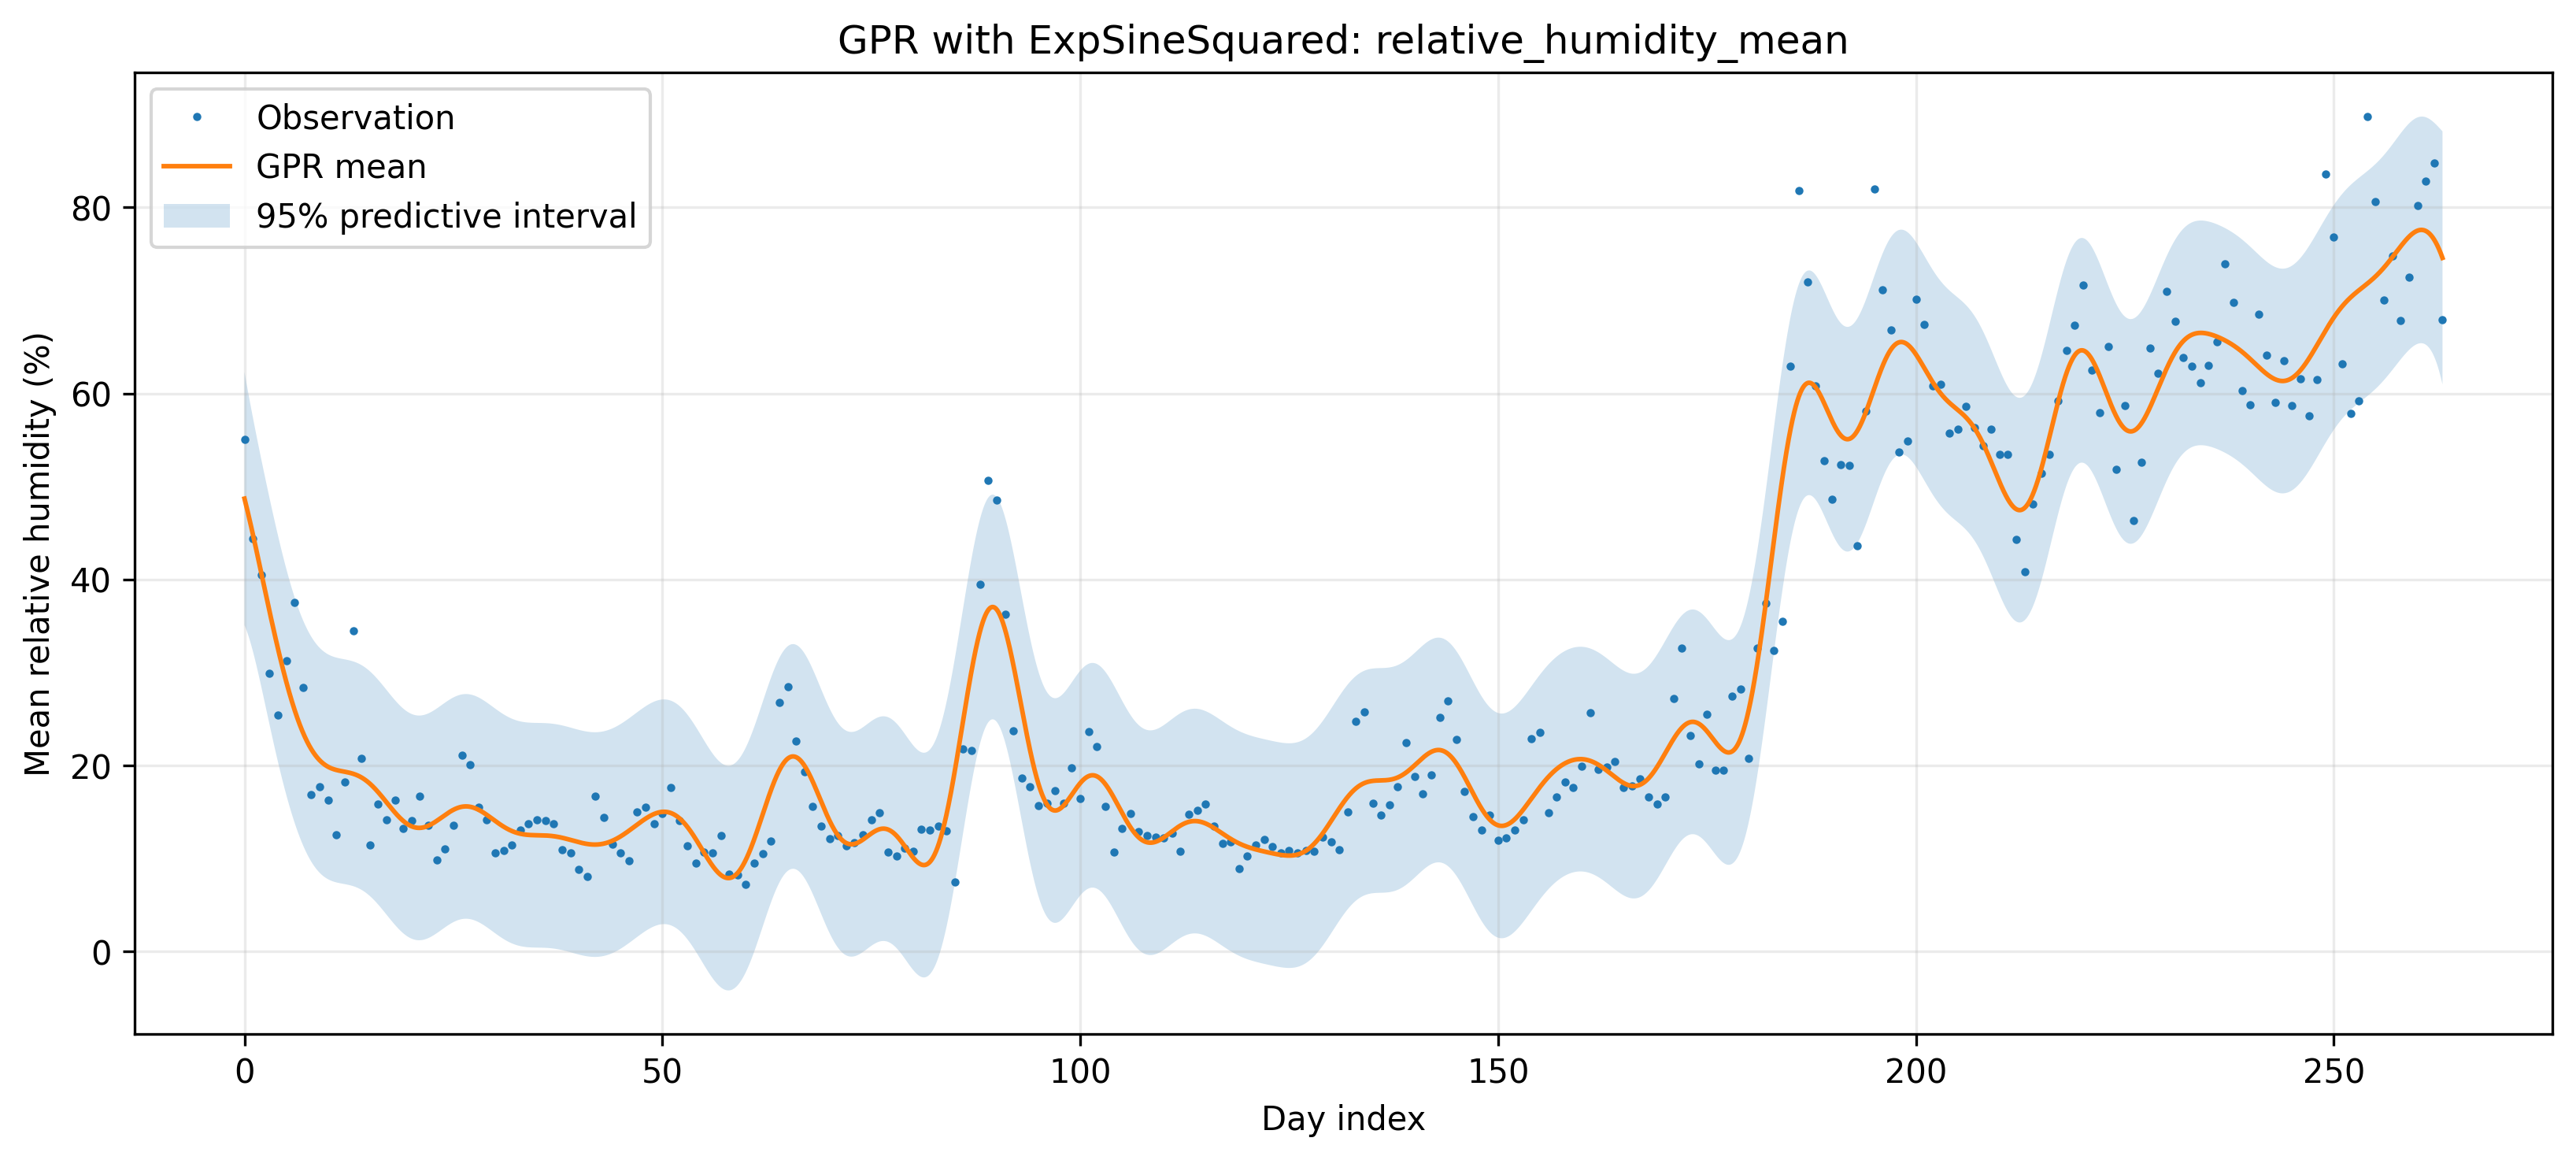

shortwave_radiation_sum_gpr.png


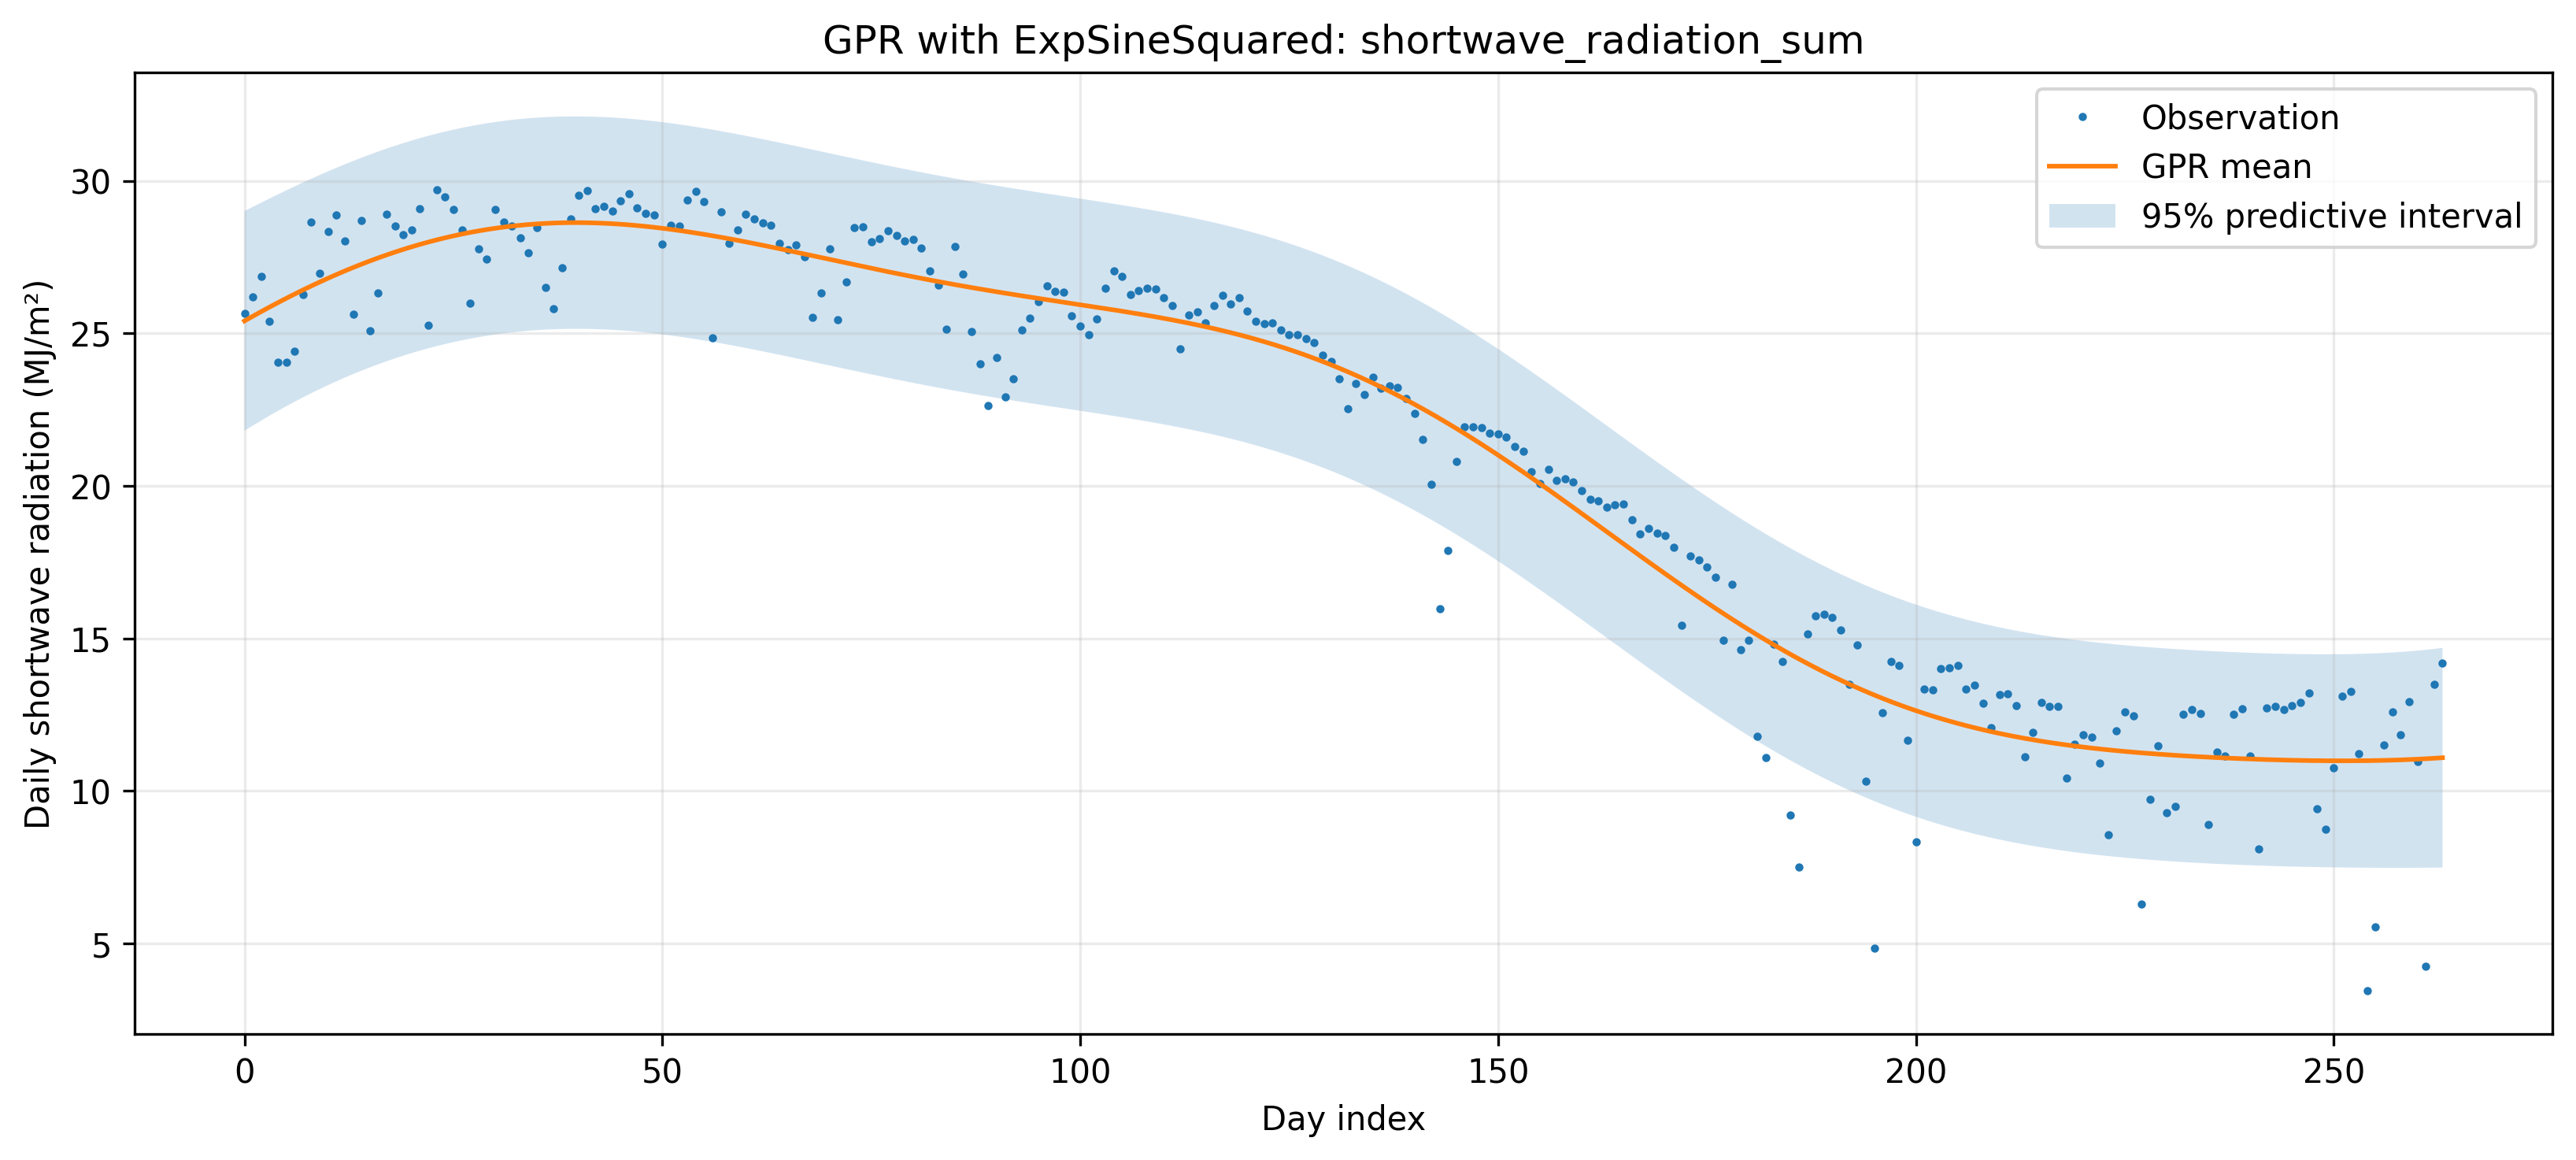

temperature_mean_gpr.png


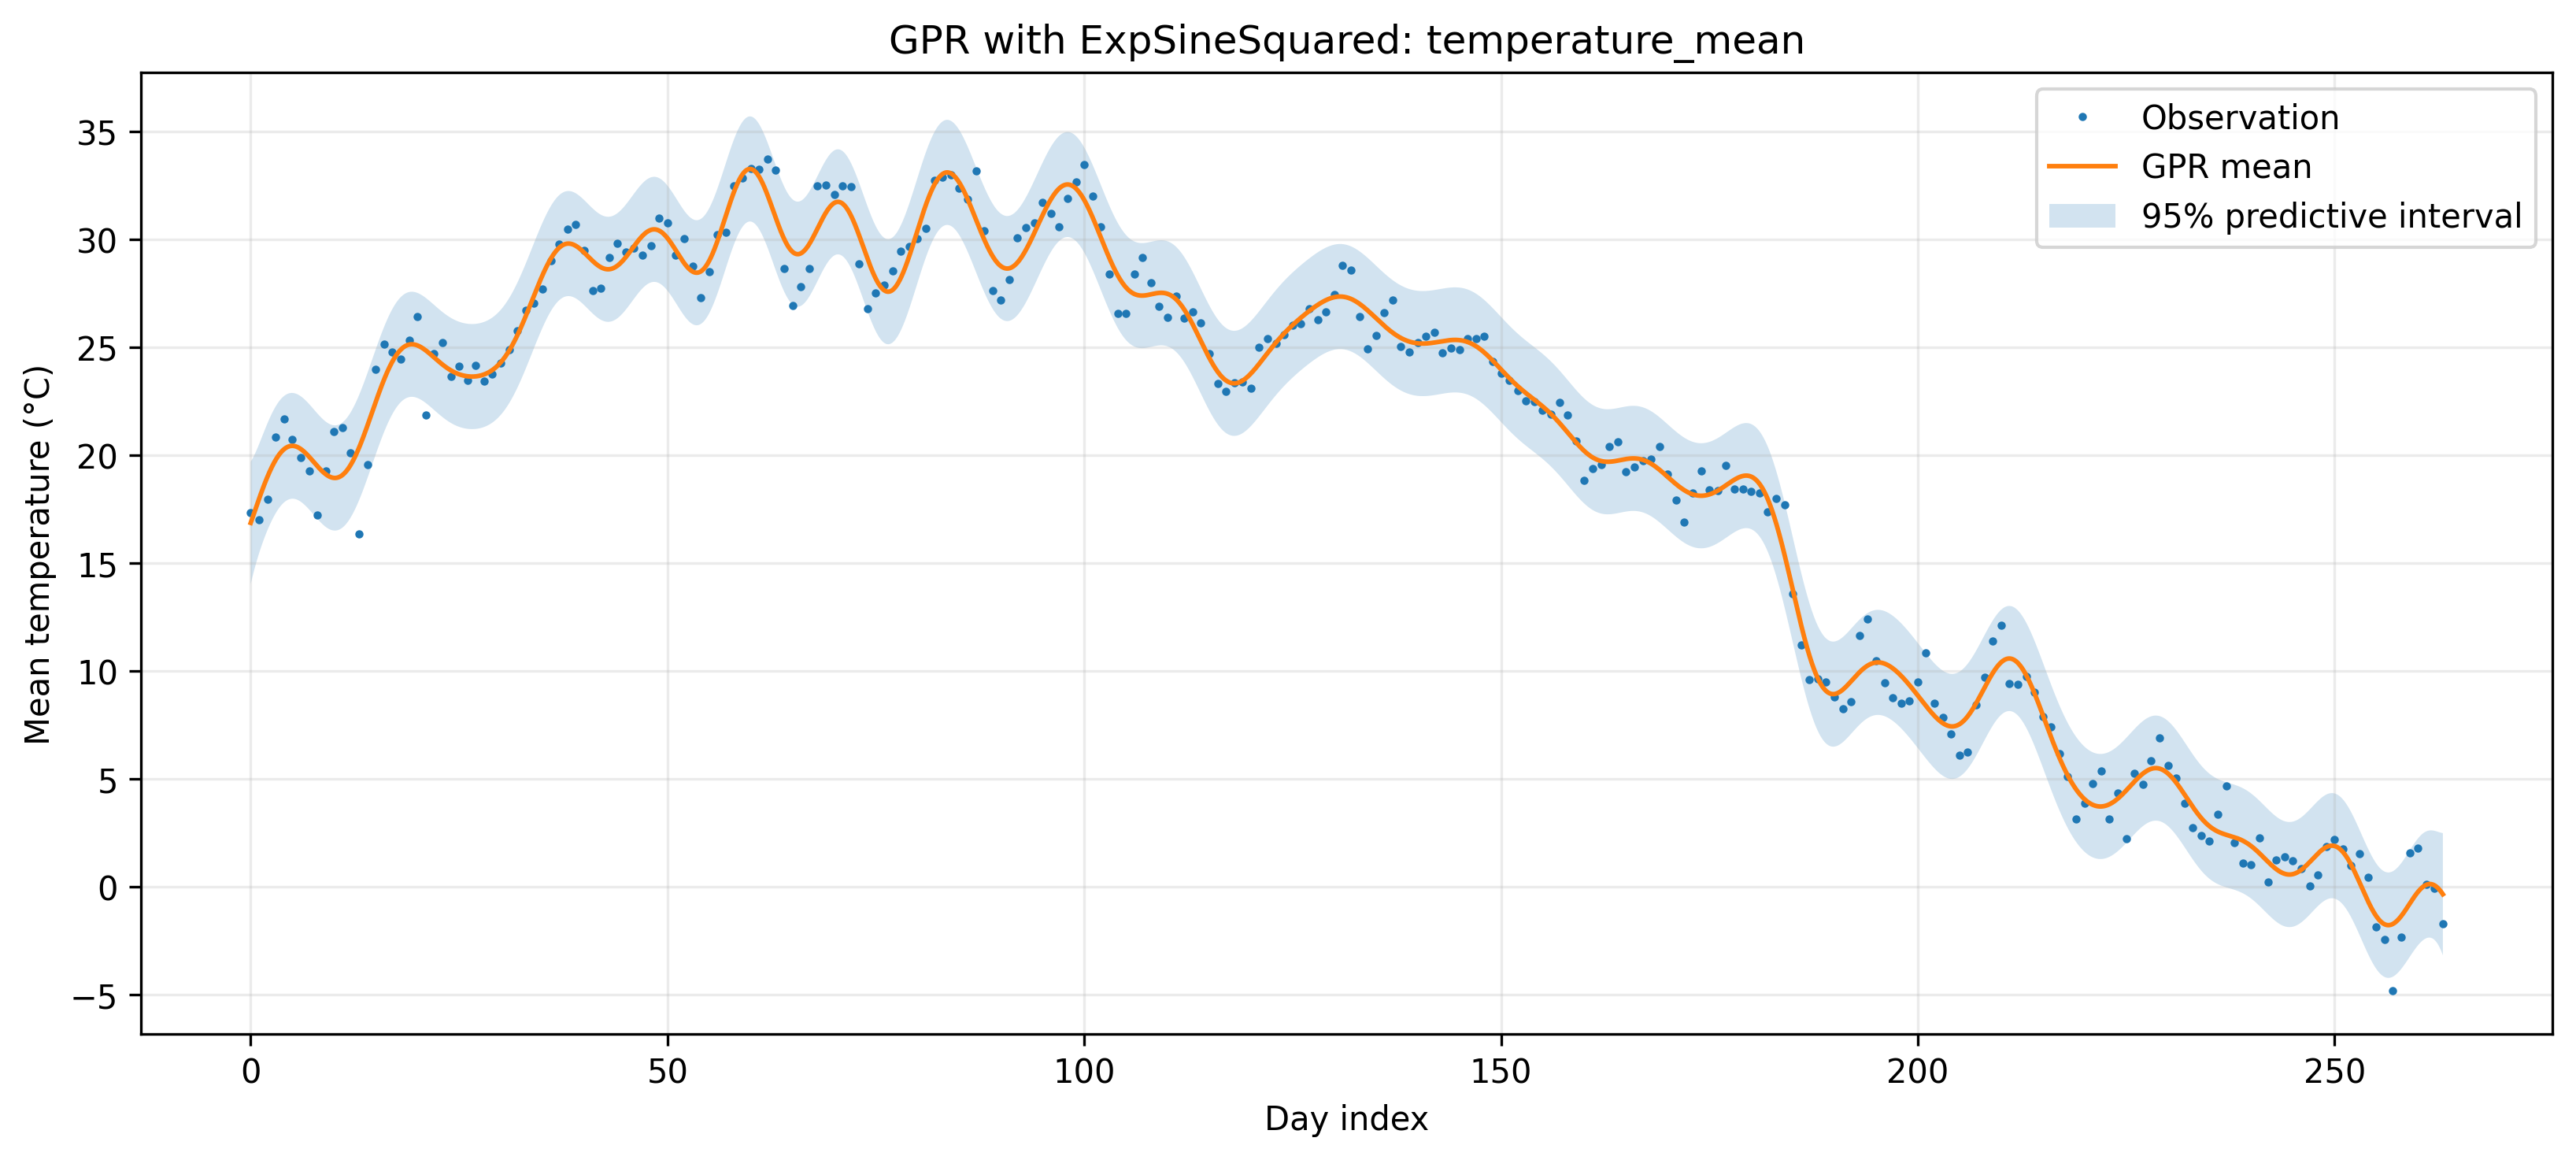

test_nrmse.png


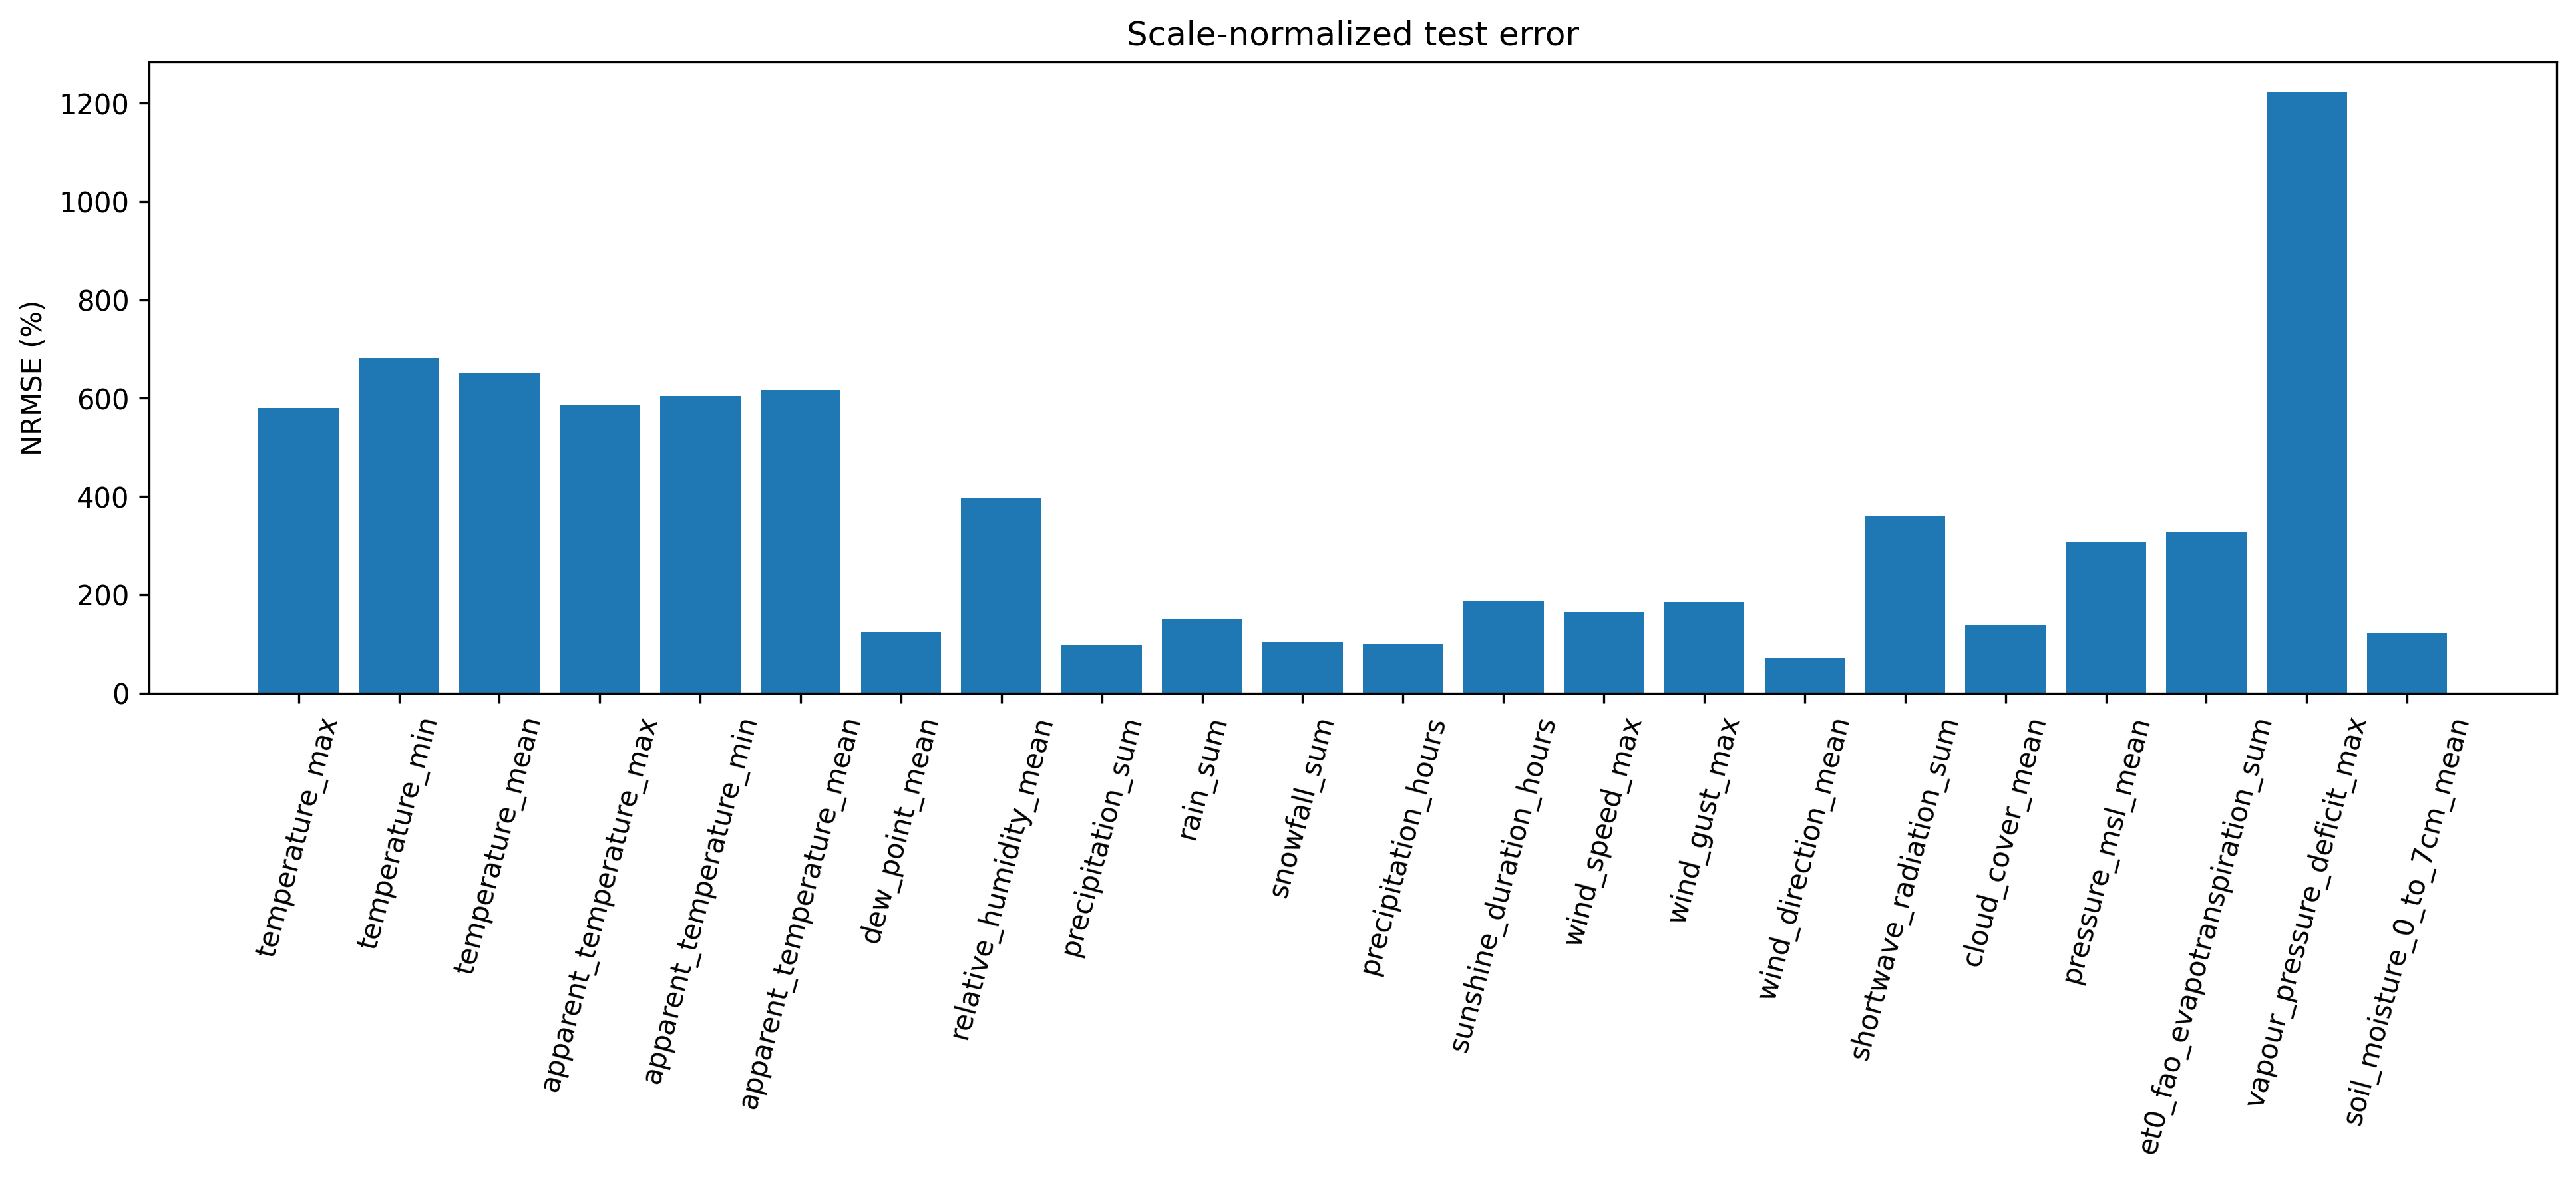

test_rmse.png


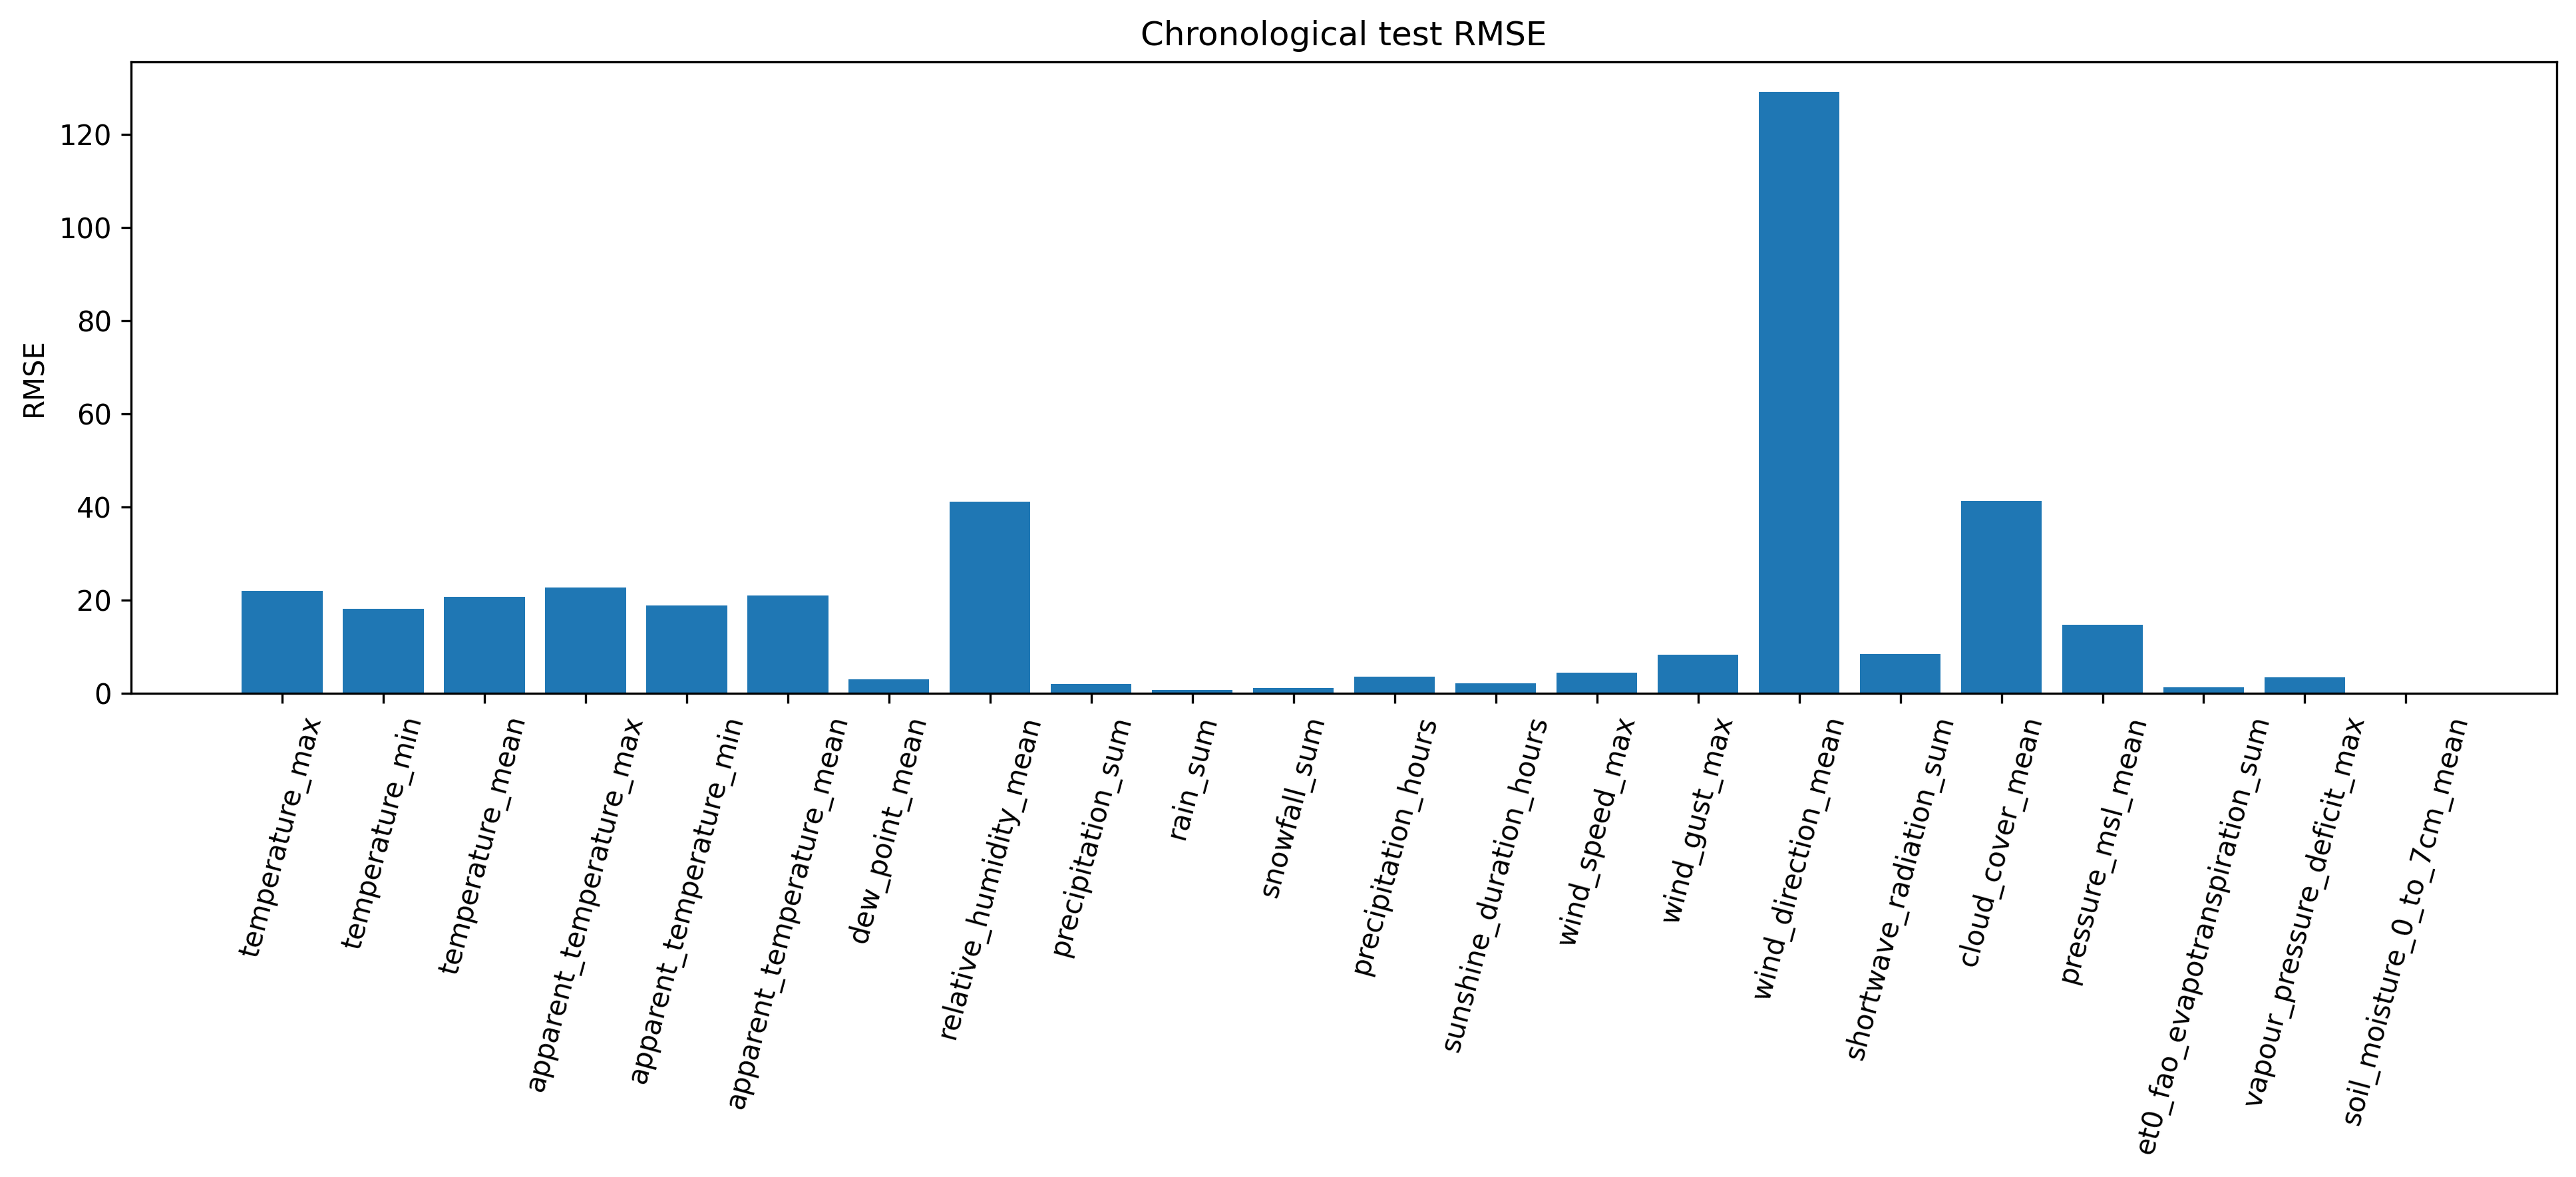

wind_speed_max_gpr.png


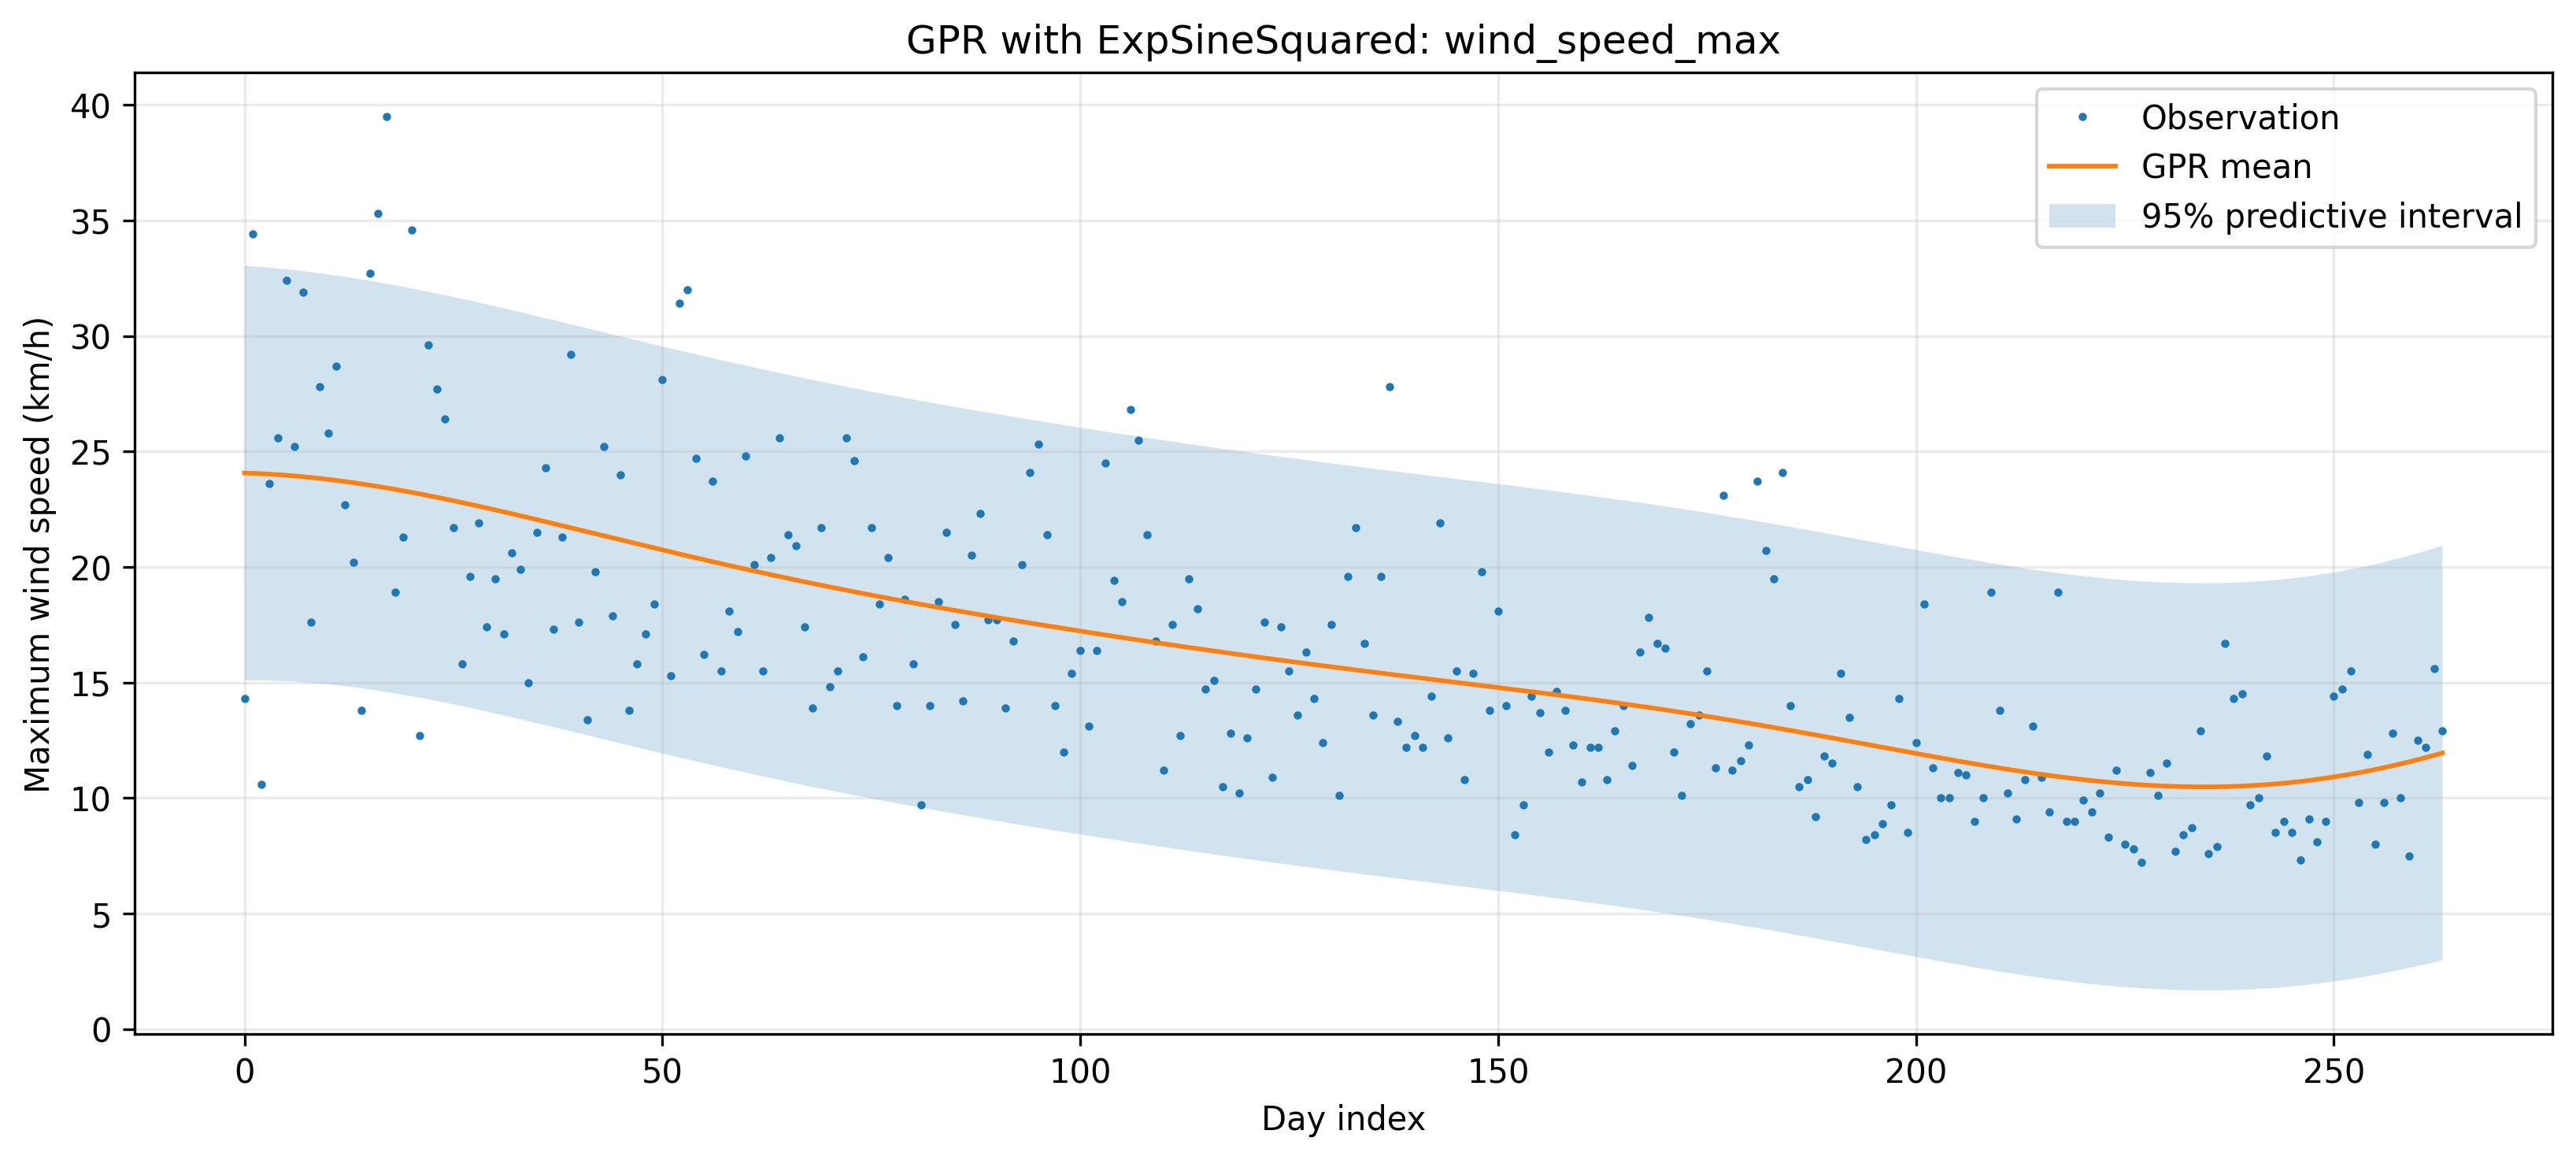

In [7]:
# Display the generated figures.
from IPython.display import display, Image

for figure_path in sorted((ROOT / "outputs" / "figures").glob("*.png")):
    print(figure_path.name)
    display(Image(filename=str(figure_path)))


In [9]:
# ============================================================================
# Final export, audit, packaging, and automatic Google Colab download
# ============================================================================

from pathlib import Path
import os
import json
import zipfile
import runpy

import pandas as pd
import nbformat as nbf


# ============================================================================
# 1. Paths
# ============================================================================

ROOT = Path(
    os.getenv(
        "ASSIGNMENT_OUTPUT_ROOT",
        Path.cwd() / "assignment_solution_runtime",
    )
).resolve()

SCRIPT_PATH = Path(
    os.getenv(
        "ASSIGNMENT_SCRIPT_PATH",
        Path.cwd() / "assignment_solution.py",
    )
).resolve()


# ============================================================================
# 2. Recover assignment_solution.py when necessary
# ============================================================================

if not SCRIPT_PATH.exists():

    try:
        history = get_ipython().user_ns.get(
            "In",
            [],
        )
    except Exception:
        history = []

    writefile_source = None

    for source in reversed(history):

        if (
            source
            and
            "%%writefile assignment_solution.py"
            in source
        ):
            writefile_source = source
            break

    if writefile_source is not None:

        lines = writefile_source.splitlines()

        magic_index = None

        for index, line in enumerate(lines):

            if (
                line.strip()
                == "%%writefile assignment_solution.py"
            ):
                magic_index = index
                break

        if magic_index is not None:

            script_text = "\n".join(
                lines[magic_index + 1:]
            ).lstrip("\n")

            SCRIPT_PATH.write_text(
                script_text,
                encoding="utf-8",
            )


if not SCRIPT_PATH.exists():

    raise FileNotFoundError(
        "assignment_solution.py was not found.\n"
        f"Expected location:\n{SCRIPT_PATH}\n\n"
        "Run the implementation cell first."
    )


# ============================================================================
# 3. Load helper functions from the complete implementation
# ============================================================================

module_namespace = runpy.run_path(
    str(SCRIPT_PATH),
    run_name="assignment_solution_module",
)

if "write_audit" not in module_namespace:

    raise RuntimeError(
        "The implementation file does not contain "
        "the required write_audit() function."
    )

if "create_package" not in module_namespace:

    raise RuntimeError(
        "The implementation file does not contain "
        "the required create_package() function."
    )

write_audit = module_namespace["write_audit"]
create_package = module_namespace["create_package"]


# ============================================================================
# 4. Verify the pipeline results
# ============================================================================

metrics_path = (
    ROOT
    / "outputs"
    / "tables"
    / "test_metrics.csv"
)

if not metrics_path.exists():

    raise FileNotFoundError(
        "The test metrics file does not exist:\n"
        f"{metrics_path}\n\n"
        "Run the complete pipeline before exporting the final package."
    )

metrics = pd.read_csv(
    metrics_path
)


# ============================================================================
# 5. Create the final audit report
# ============================================================================

audit_path = write_audit(
    ROOT,
    metrics,
)

if not audit_path.exists():

    raise RuntimeError(
        "The audit report was not created."
    )


# ============================================================================
# 6. Build a clean self-contained notebook
# ============================================================================

notebook_path = (
    ROOT
    / "assignment_solution.ipynb"
)

script_text = SCRIPT_PATH.read_text(
    encoding="utf-8",
)


# The notebook uses %%writefile so the complete implementation
# remains readable instead of being stored as a giant Python string.
implementation_cell = (
    "%%writefile assignment_solution.py\n"
    + script_text
)

run_cell = r'''# Load and execute the complete implementation.

from pathlib import Path
import os
import runpy
import json

ROOT = Path(
    os.getenv(
        "ASSIGNMENT_OUTPUT_ROOT",
        Path.cwd() / "assignment_solution_runtime",
    )
).resolve()

os.environ["ASSIGNMENT_TEST_MODE"] = "0"
os.environ["ASSIGNMENT_OUTPUT_ROOT"] = str(ROOT)

namespace = runpy.run_path(
    "assignment_solution.py",
    run_name="assignment_solution_module",
)

summary = namespace["run"](ROOT)

print(json.dumps(summary, indent=2, default=str))
'''

export_cell = r'''# Final export and automatic Colab download.

from pathlib import Path
import os
import zipfile

ROOT = Path(
    os.getenv(
        "ASSIGNMENT_OUTPUT_ROOT",
        Path.cwd() / "assignment_solution_runtime",
    )
).resolve()

notebook_path = ROOT / "assignment_solution.ipynb"
script_path = ROOT / "assignment_solution.py"
audit_path = ROOT / "changes_audit_and_validation_report.md"
package_path = ROOT / "assignment_submission_package.zip"

required_files = [
    notebook_path,
    script_path,
    audit_path,
]

for file_path in required_files:
    if not file_path.exists():
        raise FileNotFoundError(
            f"Required artifact was not created:\n{file_path}"
        )

with zipfile.ZipFile(
    package_path,
    "w",
    zipfile.ZIP_DEFLATED,
) as archive:

    for file_path in required_files:
        archive.write(
            file_path,
            file_path.name,
        )

    for folder in [
        ROOT / "data",
        ROOT / "outputs",
    ]:

        if folder.exists():

            for file_path in sorted(
                folder.rglob("*")
            ):

                if (
                    file_path.is_file()
                    and file_path != package_path
                ):

                    archive.write(
                        file_path,
                        file_path.relative_to(ROOT),
                    )

print(f"Notebook : {notebook_path}")
print(f"Python   : {script_path}")
print(f"Audit    : {audit_path}")
print(f"ZIP      : {package_path}")

try:
    from google.colab import files

    files.download(
        str(package_path)
    )

    print(
        "Google Colab download started."
    )

except Exception:

    print(
        "Outside Google Colab. "
        "The ZIP package remains on disk."
    )
'''


notebook = nbf.v4.new_notebook(
    cells=[
        nbf.v4.new_markdown_cell(
            """# Assignment Solution — Gaussian Process Regression for Esfahan Weather

This notebook downloads a real weather CSV, builds the validated daily dataset,
fits the Gaussian-process models, evaluates the chronological test split,
generates the required artifacts, and packages the complete submission.
"""
        ),
        nbf.v4.new_code_cell(
            implementation_cell
        ),
        nbf.v4.new_code_cell(
            run_cell
        ),
        nbf.v4.new_code_cell(
            export_cell
        ),
    ],
    metadata={
        "kernelspec": {
            "display_name": "Python 3",
            "language": "python",
            "name": "python3",
        },
        "language_info": {
            "name": "python",
        },
        "colab": {
            "name": "assignment_solution.ipynb",
        },
    },
)

nbf.write(
    notebook,
    notebook_path,
)


# ============================================================================
# 7. Make sure the Python implementation inside the package is current
# ============================================================================

runtime_script_path = (
    ROOT
    / "assignment_solution.py"
)

runtime_script_path.write_text(
    script_text,
    encoding="utf-8",
)


# ============================================================================
# 8. Create the final ZIP package
# ============================================================================

package_path = create_package(
    ROOT,
    script_path=runtime_script_path,
    notebook_path=notebook_path,
    audit_path=audit_path,
)


# ============================================================================
# 9. Final verification
# ============================================================================

for file_path in [
    notebook_path,
    runtime_script_path,
    audit_path,
    package_path,
]:

    if not file_path.exists():

        raise RuntimeError(
            f"Final artifact missing:\n{file_path}"
        )

print()
print("=" * 80)
print("FINAL EXPORT COMPLETED SUCCESSFULLY")
print("=" * 80)
print()

print(
    f"Notebook : {notebook_path}"
)

print(
    f"Python   : {runtime_script_path}"
)

print(
    f"Audit    : {audit_path}"
)

print(
    f"ZIP      : {package_path}"
)


# ============================================================================
# 10. Automatic Google Colab download
# ============================================================================

try:

    from google.colab import files

    files.download(
        str(package_path)
    )

    print(
        "\nGoogle Colab download started."
    )

except Exception:

    print(
        "\nNot running in Google Colab. "
        "The package remains available on disk."
    )


FINAL EXPORT COMPLETED SUCCESSFULLY

Notebook : /content/assignment_solution_runtime/assignment_solution.ipynb
Python   : /content/assignment_solution_runtime/assignment_solution.py
Audit    : /content/assignment_solution_runtime/changes_audit_and_validation_report.md
ZIP      : /content/assignment_solution_runtime/assignment_submission_package.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


Google Colab download started.
